# Notebook 01 — Exploratory Data Analysis & Feature Engineering
## FixtureIQ · Multi-Season Data Integration (2022/23 – 2024/25)

### What this notebook does
1. **Loads and unifies** all data sources across 3 seasons:
   - FBref match logs (`*_matches_all.csv`) — team-level match calendar
   - FBref player stats (`*_players_all_competitions.csv`) — season aggregates
   - SofaScore position profiles (`position_profiles/*.csv`) — rich per-position metrics
   - Injuries data (`injuries/` folder) — if available
2. **Descriptive statistics** — mean, std, min, max, CV per variable
3. **Missing value analysis** — visual missingness maps
4. **Outlier detection** — IQR method, flagged and visualised
5. **Distribution analysis** — histograms for all key variables
6. **Correlation matrix & heatmap** — Pearson + Spearman
7. **Radar charts** — player/team performance profiles by position
8. **Lorenz curve & Gini coefficient** — workload inequality between players
9. **New computed attributes** — fatigue indicators, workload stress index, performance composite
10. **Written conclusions** — interpretations after each main section

### File structure expected
```
Data/
├── 2022-2023/
│   ├── fbref/
│   │   ├── arsenal_2022_2023/         → *_matches_all.csv, *_players_all_competitions.csv
│   │   ├── manchester_city_2022_2023/
│   │   ├── liverpool_2022_2023/         (or chelsea / tottenham depending on UCL year)
│   │   └── .../
│   ├── sofascore/
│   │   ├── champions_league/           → *_all_players.csv, position_profiles/
│   │   └── premier_league/             → *_all_players.csv, position_profiles/
│   └── injuries/                       → optional injury CSV files
├── 2023-2024/   (same structure)
└── 2024-2025/   (same structure)
```

## 0. Setup

In [3]:
# Uncomment first time
# !pip install pandas numpy matplotlib seaborn scipy --quiet

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
import math

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5)})
sns.set_palette('husl')

# ── Paths ─────────────────────────────────────────────────────────────────────
# !! ADJUST THIS to your actual data root !!
path = r'C:\Users\ItxaroAizpuruaArcona\Desktop\S_A\Fixture-IQ-playground\Data'
DATA_ROOT = Path(path)
OUTPUT_DIR = DATA_ROOT / 'EDA_OUTPUTS'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# ── Season / team config ──────────────────────────────────────────────────────
SEASONS = {
    '2022-2023': '2022_2023',
    '2023-2024': '2023_2024',
    '2024-2025': '2024_2025',
}

# UCL-participating PL teams per season
# Adjust if your data has different teams for 22/23 or 23/24
UCL_TEAMS_BY_SEASON = {
    '2022-2023': ['Chelsea', 'Liverpool', 'Manchester City', 'Tottenham'],
    '2023-2024': ['Arsenal', 'Manchester City', 'Manchester United', 'Newcastle United'],
    '2024-2025': ['Arsenal', 'Liverpool', 'Manchester City', 'Aston Villa'],
}

TEAM_SLUGS = {
    'Arsenal':           'arsenal',
    'Manchester City':   'manchester_city',
    'Liverpool':         'liverpool',
    'Aston Villa':       'aston_villa',
    'Chelsea':           'chelsea',
    'Manchester United': 'manchester_united',
    'Newcastle United':  'newcastle_united',
    'Tottenham':         'tottenham_hotspur',
}

TEAM_COLORS = {
    'Arsenal':           '#EF0107',
    'Liverpool':         '#C8102E',
    'Manchester City':   '#6CABDD',
    'Aston Villa':       '#670E36',
    'Chelsea':           '#034694',
    'Manchester United': '#DA291C',
    'Newcastle United':  '#241F20',
    'Tottenham':         '#132257',
}

print('Setup complete.')
print(f'Data root : {DATA_ROOT}')
print(f'Output    : {OUTPUT_DIR}')

Setup complete.
Data root : C:\Users\ItxaroAizpuruaArcona\Desktop\S_A\Fixture-IQ-playground\Data
Output    : C:\Users\ItxaroAizpuruaArcona\Desktop\S_A\Fixture-IQ-playground\Data\EDA_OUTPUTS


---
## 1. Load Data — FBref Match Logs

In [50]:
def load_fbref_matches(data_root: Path, seasons: dict, ucl_teams_by_season: dict) -> pd.DataFrame:
    """Load *_matches_all.csv for every team × season from the fbref subfolder."""
    frames = []
    for season_dir, ucl_teams in ucl_teams_by_season.items():
        fbref_root = data_root / season_dir / 'fbref'
        print(f'Loading season {season_dir}')
        if not fbref_root.exists():
            # Fallback: season folder directly (older structure)
            fbref_root = data_root / f'SEASON_{season_slug}'
            print(f'  ✗ {season_dir}: fbref folder not found, trying {fbref_root}...')
        for team_name in ucl_teams:
            season_slug = seasons.get(season_dir)
            slug = TEAM_SLUGS.get(team_name)
            if not slug:
                print(f'  ✗ {team_name}: no slug found')
                continue
            # Try both naming conventions
            candidates = [
                fbref_root / f'{slug}_{season_slug}' / f'{slug}_{season_slug}_matches_all.csv',
                fbref_root / f'{slug}_{season_slug}' / f'{slug}_{season_slug}_matches_all.csv',
            ]
            # Also glob for any *matches_all.csv inside the team folder
            team_folders = list(fbref_root.glob(f'{slug}*'))
            for tf in team_folders:
                candidates += list(tf.glob('*matches_all.csv'))

            loaded = False
            for path in candidates:
                if path.exists():
                    df = pd.read_csv(path)
                    df['team'] = team_name
                    df['season'] = season_dir
                    frames.append(df)
                    print(f'  ✓ {team_name} {season_dir}: {len(df)} matches ← {path.name}')
                    loaded = True
                    break
            if not loaded:
                print(f'  ✗ {team_name} {season_dir}: not found')
        print("\n")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


print('Loading FBref match logs...\n')
df_matches_raw = load_fbref_matches(DATA_ROOT, SEASONS, UCL_TEAMS_BY_SEASON)
print(f'\nTotal rows loaded: {len(df_matches_raw):,}')

Loading FBref match logs...

Loading season 2022-2023
  ✓ Chelsea 2022-2023: 50 matches ← chelsea_2022_2023_matches_all.csv
  ✓ Liverpool 2022-2023: 52 matches ← liverpool_2022_2023_matches_all.csv
  ✓ Manchester City 2022-2023: 61 matches ← manchester_city_2022_2023_matches_all.csv
  ✓ Tottenham 2022-2023: 50 matches ← tottenham_hotspur_2022_2023_matches_all.csv


Loading season 2023-2024
  ✓ Arsenal 2023-2024: 52 matches ← arsenal_2023_2024_matches_all.csv
  ✓ Manchester City 2023-2024: 57 matches ← manchester_city_2023_2024_matches_all.csv
  ✓ Manchester United 2023-2024: 52 matches ← manchester_united_2023_2024_matches_all.csv
  ✓ Newcastle United 2023-2024: 51 matches ← newcastle_united_2023_2024_matches_all.csv


Loading season 2024-2025
  ✓ Arsenal 2024-2025: 58 matches ← arsenal_2024_2025_matches_all.csv
  ✓ Liverpool 2024-2025: 56 matches ← liverpool_2024_2025_matches_all.csv
  ✓ Manchester City 2024-2025: 57 matches ← manchester_city_2024_2025_matches_all.csv
  ✓ Aston Villa 

In [51]:
# ── Standardise match log columns ─────────────────────────────────────────────
def standardise_matches(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # Normalise column names
    col_map = {
        'Date': 'date', 'Competition': 'competition', 'Venue': 'home_away',
        'Result': 'result', 'GF': 'goals_for', 'GA': 'goals_against',
        'Opponent': 'opponent', 'Round': 'round', 'Day': 'day',
    }
    df = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})
    # Also lowercase any already lowercase variants
    df.columns = df.columns.str.strip()

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['goals_for']     = pd.to_numeric(df.get('goals_for', np.nan), errors='coerce')
    df['goals_against'] = pd.to_numeric(df.get('goals_against', np.nan), errors='coerce')
    df['goal_diff']     = df['goals_for'] - df['goals_against']

    # Points from result
    result_col = next((c for c in df.columns if c.lower() == 'result'), None)
    if result_col:
        df['points'] = df[result_col].map({'W': 3, 'D': 1, 'L': 0})

    # Competition category
    def comp_cat(c):
        c = str(c).lower()
        if 'premier' in c: return 'Premier League'
        if 'champions' in c or 'champions lg' in c: return 'Champions League'
        if 'fa cup' in c: return 'FA Cup'
        if 'efl' in c or 'carabao' in c or 'league cup' in c: return 'EFL Cup'
        return 'Other'
    df['competition_cat'] = df['competition'].apply(comp_cat)

    # Rest days (per team, chronological)
    df = df.sort_values(['team', 'season', 'date'])
    df['rest_days'] = df.groupby(['team', 'season'])['date'].transform(
        lambda x: x.diff().dt.days
    )
    df['short_rest'] = (df['rest_days'] <= 4).astype(float)
    df['very_short_rest'] = (df['rest_days'] <= 3).astype(float)

    # Rolling match density
    def rolling_density(group, window_days):
        g = group.set_index('date').sort_index()
        g['_one'] = 1
        return (g['_one'].rolling(f'{window_days}D', min_periods=1).sum() - 1).values

    df['matches_last_7d']  = df.groupby(['team','season'], group_keys=False).apply(
        lambda g: pd.Series(rolling_density(g, 7),  index=g.index)).clip(lower=0)
    df['matches_last_14d'] = df.groupby(['team','season'], group_keys=False).apply(
        lambda g: pd.Series(rolling_density(g, 14), index=g.index)).clip(lower=0)

    # Season phase
    month = df['date'].dt.month
    season_phase_map = {
        1: 'Jan', 2: 'Jan',
        3: 'Spring', 4: 'Spring', 5: 'Spring',
        6: 'End',
        7: 'Early', 8: 'Early', 9: 'Early',
        10: 'Winter', 11: 'Winter', 12: 'Winter'
    }
    df['season_phase'] = month.map(season_phase_map)

    # UCL match flag
    df['is_ucl'] = (df['competition_cat'] == 'Champions League').astype(int)
    df['is_away'] = (df['home_away'].str.lower() == 'away').astype(int) \
        if 'home_away' in df.columns else 0

    return df.reset_index(drop=True)


df_matches = standardise_matches(df_matches_raw)
print(f'Match calendar: {len(df_matches):,} rows × {len(df_matches.columns)} cols')
print(f'Seasons   : {df_matches["season"].unique().tolist()}')
print(f'Teams     : {sorted(df_matches["team"].unique().tolist())}')
print(f'Date range: {df_matches["date"].min().date()} → {df_matches["date"].max().date()}')
df_matches.head(-10)

Match calendar: 653 rows × 32 cols
Seasons   : ['2023-2024', '2024-2025', '2022-2023']
Teams     : ['Arsenal', 'Aston Villa', 'Chelsea', 'Liverpool', 'Manchester City', 'Manchester United', 'Newcastle United', 'Tottenham']
Date range: 2022-07-30 → 2025-05-25


,date,start_time,competition,round,day,home_away,result,goals_for,goals_against,opponent,possession,attendance,captain,formation,opp_formation,referee,Match_Report_URL,Match_Report,notes,team,season,goal_diff,points,competition_cat,rest_days,short_rest,very_short_rest,matches_last_7d,matches_last_14d,season_phase,is_ucl,is_away
0,2023-08-06,16:00(17:00),Community Shield,FA Community Shield,Sun,Neutral,D,NaN,NaN,Manchester City,45.000,"81,145",Martin Ødegaard,4-3-3,4-2-3-1,Stuart Attwell,https://fbref.com/en/matches/10e5c045/Arsenal-...,Match Report,NaN,Arsenal,2023-2024,NaN,1,Other,NaN,0.000,0.000,0.000,0.000,Early,0,0
1,2023-08-12,12:30(13:30),Premier League,Matchweek 1,Sat,Home,W,2.000,1.000,Nottingham Forest,79.000,"59,984",Martin Ødegaard,4-3-3,3-4-3,Michael Oliver,https://fbref.com/en/matches/26a7f90c/Arsenal-...,Match Report,NaN,Arsenal,2023-2024,1.000,3,Premier League,6.000,0.000,0.000,1.000,1.000,Early,0,0
2,2023-08-21,20:00(21:00),Premier League,Matchweek 2,Mon,Away,W,1.000,0.000,Crystal Palace,54.000,"24,189",Martin Ødegaard,4-3-3,4-2-3-1,David Coote,https://fbref.com/en/matches/3b5ecd36/Crystal-...,Match Report,NaN,Arsenal,2023-2024,1.000,3,Premier League,9.000,0.000,0.000,0.000,1.000,Early,0,1
3,2023-08-26,15:00(16:00),Premier League,Matchweek 3,Sat,Home,D,2.000,2.000,Fulham,71.000,"59,961",Martin Ødegaard,4-3-3,4-3-3,Paul Tierney,https://fbref.com/en/matches/d8f8f8ad/Arsenal-...,Match Report,NaN,Arsenal,2023-2024,0.000,1,Premier League,5.000,0.000,0.000,1.000,1.000,Early,0,0
4,2023-09-03,16:30(17:30),Premier League,Matchweek 4,Sun,Home,W,3.000,1.000,Manchester Utd,55.000,"60,192",Martin Ødegaard,4-1-4-1,4-2-3-1,Anthony Taylor,https://fbref.com/en/matches/74125d47/Arsenal-...,Match Report,NaN,Arsenal,2023-2024,2.000,3,Premier League,8.000,0.000,0.000,0.000,2.000,Early,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,2023-03-01,19:55(20:55),FA Cup,Fifth round proper,Wed,Away,L,0.000,1.000,Sheffield United,53.000,"28,308",Eric Dier,3-4-3,3-5-1-1,John Brooks,https://fbref.com/en/matches/e6e74c21/Sheffiel...,Match Report,NaN,Tottenham,2022-2023,-1.000,0,FA Cup,3.000,1.000,1.000,1.000,2.000,Spring,0,1
639,2023-03-04,15:00(16:00),Premier League,Matchweek 26,Sat,Away,L,0.000,1.000,Wolves,54.000,"31,585",Harry Kane,3-4-3,4-2-3-1,Tim Robinson,https://fbref.com/en/matches/bf4ac62d/Wolverha...,Match Report,NaN,Tottenham,2022-2023,-1.000,0,Premier League,3.000,1.000,1.000,2.000,3.000,Spring,0,1
640,2023-03-08,20:00(21:00),Champions Lg,Round of 16,Wed,Home,D,0.000,0.000,itMilan,54.000,"61,602",Harry Kane,3-4-3,4-3-3,Clément Turpin,https://fbref.com/en/matches/ee8accc3/Tottenha...,Match Report,Leg 2 of 2; Milan won,Tottenham,2022-2023,0.000,1,Champions League,4.000,1.000,0.000,1.000,3.000,Spring,1,0
641,2023-03-11,15:00(16:00),Premier League,Matchweek 27,Sat,Home,W,3.000,1.000,Nottingham Forest,56.000,"61,460",Harry Kane,3-4-3,4-3-2-1,Craig Pawson,https://fbref.com/en/matches/d065f9cd/Tottenha...,Match Report,NaN,Tottenham,2022-2023,2.000,3,Premier League,3.000,1.000,1.000,1.000,4.000,Spring,0,0


---
## 2. Load Data — FBref Player Season Stats

In [42]:
def load_fbref_players(data_root: Path, seasons: dict, team_slugs: dict) -> pd.DataFrame:
    """Load *_players_all_competitions.csv for every team × season."""
    frames = []
    for season_dir, season_slug in seasons.items():
        fbref_root = data_root / season_dir / 'fbref'
        if not fbref_root.exists():
            fbref_root = data_root / f'SEASON_{season_slug}'
        
        for team_name, slug in team_slugs.items():
            # Find team folder using single glob pattern
            team_folders = list(fbref_root.glob(f'{slug}*'))
            
            for tf in team_folders:
                # Load players_all_competitions CSV
                csv_files = list(tf.glob('*players_all_competitions.csv'))
                if csv_files:
                    path = csv_files[0]  # Take first match only
                    df = pd.read_csv(path)
                    df['team'] = team_name
                    df['season'] = season_dir
                    df['source'] = 'fbref'
                    frames.append(df)
                    print(f'  ✓ {team_name} {season_dir}: {len(df)} players ← {path.name}')
                    break  # One file per team per season
    
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


print('Loading FBref player stats...')
df_players_raw = load_fbref_players(DATA_ROOT, SEASONS, TEAM_SLUGS)
print(f'Total: {len(df_players_raw):,} rows')
df_players_raw.head()

Loading FBref player stats...
  ✓ Manchester City 2022-2023: 32 players ← manchester_city_2022_2023_players_all_competitions.csv
  ✓ Liverpool 2022-2023: 39 players ← liverpool_2022_2023_players_all_competitions.csv
  ✓ Chelsea 2022-2023: 41 players ← chelsea_2022_2023_players_all_competitions.csv
  ✓ Tottenham 2022-2023: 34 players ← tottenham_hotspur_2022_2023_players_all_competitions.csv
  ✓ Arsenal 2023-2024: 38 players ← arsenal_2023_2024_players_all_competitions.csv
  ✓ Manchester City 2023-2024: 32 players ← manchester_city_2023_2024_players_all_competitions.csv
  ✓ Manchester United 2023-2024: 44 players ← manchester_united_2023_2024_players_all_competitions.csv
  ✓ Newcastle United 2023-2024: 39 players ← newcastle_united_2023_2024_players_all_competitions.csv
  ✓ Arsenal 2024-2025: 42 players ← arsenal_2024_2025_players_all_competitions.csv
  ✓ Liverpool 2024-2025: 35 players ← liverpool_2024_2025_players_all_competitions.csv
  ✓ Aston Villa 2024-2025: 40 players ← aston_vill

,Player,Nation,Pos,Age,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,Matches,team,season,source
0,Rodri,esESP,"MF,DF",26,56,52,"4,465",49.600,4.000,7.000,11.000,4.000,0.000,0.000,9.000,0.000,0.080,0.140,0.220,0.080,0.220,Matches,Manchester City,2022-2023,fbref
1,Ederson,brBRA,GK,28,48,47,"4,275",47.500,0.000,1.000,1.000,0.000,0.000,0.000,5.000,0.000,0.000,0.020,0.020,0.000,0.020,Matches,Manchester City,2022-2023,fbref
2,Erling Haaland,noNOR,"FW,MF",22,53,50,"4,116",45.700,52.000,9.000,61.000,44.000,8.000,9.000,6.000,0.000,1.140,0.200,1.330,0.960,1.160,Matches,Manchester City,2022-2023,fbref
3,İlkay Gündoğan,deGER,MF,31,51,45,"3,845",42.700,11.000,6.000,17.000,11.000,0.000,1.000,5.000,0.000,0.260,0.140,0.400,0.260,0.400,Matches,Manchester City,2022-2023,fbref
4,Manuel Akanji,chSUI,"DF,MF",27,48,40,"3,815",42.400,1.000,1.000,2.000,1.000,0.000,0.000,4.000,0.000,0.020,0.020,0.050,0.020,0.050,Matches,Manchester City,2022-2023,fbref


In [54]:
# ── Standardise FBref player stats columns ────────────────────────────────────
FBREF_COL_MAP = {
    'Player':'player', 'Pos':'position', 'Age':'age', 'Nation':'nation',
    'MP':'matches_played', 'Starts':'starts', 'Min':'minutes_total',
    '90s':'nineties', 'Gls':'goals', 'Ast':'assists', 'G+A':'goals_assists',
    'G-PK':'goals_npk', 'PK':'pk_scored', 'PKatt':'pk_att',
    'CrdY':'yellow_cards', 'CrdR':'red_cards',
    'xG':'xg', 'npxG':'npxg', 'xAG':'xag', 'npxG+xAG':'npxg_xag',
    'ProgC':'prog_carries', 'ProgP':'prog_passes', 'ProgR':'prog_received',
    # Shooting
    'Sh':'shots', 'SoT':'shots_on_target', 'SoT%':'sot_pct',
    'Sh/90':'shots_per90', 'SoT/90':'sot_per90', 'G/Sh':'goals_per_shot',
    'AvgShotDist':'avg_shot_dist',
    # Passing
    'PassCmp':'pass_completed', 'PassAtt':'pass_att', 'Pass%':'pass_pct',
    'KeyPass':'key_passes', 'PassFin3':'passes_final_third',
    'PassPen':'passes_into_pen', 'CrsPen':'crosses_into_pen',
    # Defense
    'Tkl':'tackles', 'TklWon':'tackles_won', 'Int':'interceptions',
    'Tkl+Int':'tkl_int', 'Clr':'clearances', 'Blk':'blocks',
    'Press':'pressures', 'Press%':'press_pct',
    # Possession
    'Touches':'touches', 'DribSucc':'dribbles_won', 'Drib%':'dribble_pct',
    'Carries':'carries', 'ProgCarries':'prog_carries_poss',
    'Carry_Fin3':'carries_final_third',
    # Misc
    'AerWon':'aerials_won', 'Aer%':'aerial_pct', 'Recov':'recoveries',
    # Per-90 metrics
    'Gls_90':'goals_p90', 'Ast_90':'assists_p90', 'G+A_90':'goals_assists_p90',
    'G-PK_90':'goals_npk_p90', 'G+A-PK_90':'goals_assists_npk_p90',
}

df_players = df_players_raw.rename(
    columns={k: v for k, v in FBREF_COL_MAP.items() if k in df_players_raw.columns}
).copy()

# Convert numeric columns
numeric_cols = [
    'age', 'matches_played', 'starts', 'minutes_total', 'goals', 'assists',
    'xg', 'xag', 'npxg', 'shots', 'shots_on_target', 'sot_pct',
    'pass_completed', 'pass_pct', 'key_passes',
    'tackles', 'tackles_won', 'interceptions', 'clearances', 'pressures',
    'dribbles_won', 'dribble_pct', 'prog_carries', 'prog_passes',
    'aerials_won', 'aerial_pct', 'recoveries',
]
for col in numeric_cols:
    if col in df_players.columns:
        df_players[col] = pd.to_numeric(df_players[col], errors='coerce')

# Drop the 'Matches' column if it exists (contains only the word 'matches')
if 'Matches' in df_players.columns:
    df_players = df_players.drop(columns=['Matches'])

# Filter outfield players with meaningful time
if 'minutes_total' in df_players.columns:
    df_players = df_players[df_players['minutes_total'] >= 180].copy()

# Per-90 normalisation for key stats
for col in ['goals','assists','xg','xag','shots','shots_on_target','tackles',
            'interceptions','key_passes','pressures','dribbles_won','recoveries']:
    if col in df_players.columns and 'minutes_total' in df_players.columns:
        df_players[f'{col}_p90'] = (df_players[col] / df_players['minutes_total'] * 90).round(3)

print(f'FBref player stats: {len(df_players):,} rows × {len(df_players.columns)} cols')
print(f'Numeric columns: {[c for c in df_players.columns if df_players[c].dtype in ["float64","int64"]]}')
df_players.head()

FBref player stats: 68 rows × 24 cols
Numeric columns: ['age', 'matches_played', 'starts', 'minutes_total', 'nineties', 'goals', 'assists', 'goals_assists', 'goals_npk', 'pk_scored', 'pk_att', 'yellow_cards', 'red_cards', 'goals_p90', 'assists_p90', 'goals_assists_p90', 'goals_npk_p90', 'goals_assists_npk_p90']


,player,nation,position,age,matches_played,starts,minutes_total,nineties,goals,assists,goals_assists,goals_npk,pk_scored,pk_att,yellow_cards,red_cards,goals_p90,assists_p90,goals_assists_p90,goals_npk_p90,goals_assists_npk_p90,team,season,source
19,Sergio Gómez,esESP,DF,21,23,10,970.000,10.800,0.000,2.000,2.000,0.000,0.000,0.000,0.000,1.000,0.000,0.186,0.190,0.000,0.190,Manchester City,2022-2023,fbref
20,Cole Palmer,engENG,MF,20,25,7,865.000,9.600,1.000,1.000,2.000,1.000,0.000,0.000,1.000,0.000,0.104,0.104,0.210,0.100,0.210,Manchester City,2022-2023,fbref
21,Kalvin Phillips,engENG,"DF,MF",26,21,4,608.000,6.800,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,Manchester City,2022-2023,fbref
52,Stefan Bajcetic,esESP,MF,17,19,11,958.000,10.600,1.000,0.000,1.000,1.000,0.000,0.000,4.000,0.000,0.094,0.000,0.090,0.090,0.090,Liverpool,2022-2023,fbref
53,Fabio Carvalho,ptPOR,FW,19,21,8,646.000,7.200,3.000,0.000,3.000,3.000,0.000,0.000,0.000,0.000,0.418,0.000,0.420,0.420,0.420,Liverpool,2022-2023,fbref


---
## 3. Load Data — SofaScore Position Profiles

In [76]:
def load_sofascore_profiles(data_root: Path, seasons: dict) -> pd.DataFrame:
    """Load SofaScore position profile CSVs for all seasons."""
    frames = []
    for season_dir, season_slug in seasons.items():
        ss_root = data_root / season_dir / 'sofascore'
        if not ss_root.exists():
            print(f'  ✗ SofaScore root not found: {ss_root}')
            continue
        comp_path = ss_root / 'premier_league'
        # Load all_players.csv
        all_players = list(comp_path.glob('*all_players.csv'))
        for fp in all_players:
            df = pd.read_csv(fp)
            df['season'] = season_dir
            df['competition_source'] = 'premier_league'
            df['source'] = 'sofascore'
            frames.append(df)
            print(f'  ✓ SofaScore premier_league {season_dir}: {len(df)} players ← {fp.name}')
        # Also load position profiles
        prof_dir = comp_path / 'position_profiles'
        if prof_dir.exists():
            for fp in sorted(prof_dir.glob('*.csv')):
                df = pd.read_csv(fp)
                df['season'] = season_dir
                df['competition_source'] = 'premier_league'
                # df['position_profile_file'] = fp.stem
                df['source'] = 'sofascore_profile'
                frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


print('Loading SofaScore data...')
df_sofascore_raw = load_sofascore_profiles(DATA_ROOT, SEASONS)
print(f'Total SofaScore rows: {len(df_sofascore_raw):,}')

Loading SofaScore data...
  ✓ SofaScore premier_league 2022-2023: 554 players ← premier_league_2022_2023_all_players.csv
  ✓ SofaScore premier_league 2023-2024: 570 players ← premier_league_2023_2024_all_players.csv
  ✓ SofaScore premier_league 2024-2025: 562 players ← premier_league_2024_2025_all_players.csv
Total SofaScore rows: 11,802


In [80]:
# ── Standardise SofaScore columns ────────────────────────────────────────────
SS_COL_MAP = {
    'name': 'player',
    'minutesPlayed':            'minutes_total',
    'appearances':              'matches_played',
    'rating':                   'ss_rating',
    'goals':                    'goals',
    'goalAssist':               'assists',
    'keyPasses':                'key_passes',
    'bigChancesCreated':        'big_chances_created',
    'successfulDribbles':       'dribbles_won',
    'dribbleAttempts':          'dribble_attempts',
    'dribbleSuccessRate':       'dribble_pct',
    'accurateCrosses':          'accurate_crosses',
    'crossAttempts':            'cross_attempts',
    'crossAccuracy':            'cross_accuracy',
    'tackles':                  'tackles',
    'interceptions':            'interceptions',
    'clearances':               'clearances',
    'blockedShots':             'blocked_shots',
    'errorLeadToGoal':          'errors',
    'aerialDuelsWon':           'aerials_won',
    'aerialDuelsPercentage':    'aerial_pct',
    'groundDuelsWon':           'ground_duels_won',
    'groundDuelsPercentage':    'ground_duel_pct',
    'successfulDuelsPercentage':'duel_success_pct',
    'passAccuracy':             'pass_pct',
    'accurateLongBalls':        'accurate_long_balls',
    'longBallAccuracy':         'long_ball_pct',
    'ballRecovery':             'recoveries',
    'saves':                    'saves',
    'goalsConceded':            'goals_conceded',
    'cleanSheets':              'clean_sheets',
    'shotsOnTarget':            'shots_on_target',
    'totalShots':               'shots',
    'bigChances':               'big_chances',
    'bigChancesMissed':         'big_chances_missed',
}

df_sofascore = df_sofascore_raw.rename(
    columns={k: v for k, v in SS_COL_MAP.items() if k in df_sofascore_raw.columns}
).copy()

# Convert numeric
ss_numeric = ['minutes_total','matches_played','ss_rating','goals','assists',
              'key_passes','dribbles_won','dribble_pct','tackles','interceptions',
              'clearances','aerials_won','aerial_pct','pass_pct','recoveries']
for c in ss_numeric:
    if c in df_sofascore.columns:
        df_sofascore[c] = pd.to_numeric(df_sofascore[c], errors='coerce')

print(f'SofaScore cleaned: {len(df_sofascore):,} rows × {len(df_sofascore.columns)} cols')
df_sofascore.head(3)

SofaScore cleaned: 11,802 rows × 118 cols


,accurateChippedPasses,accurate_crosses,accurateCrossesPercentage,accurateFinalThirdPasses,accurate_long_balls,accurateLongBallsPercentage,accurateOppositionHalfPasses,accurateOwnHalfPasses,accuratePasses,accuratePassesPercentage,aerials_won,aerialDuelsWonPercentage,aerialLost,matches_played,assists,attemptPenaltyMiss,attemptPenaltyPost,attemptPenaltyTarget,recoveries,big_chances_created,big_chances_missed,blocked_shots,cleanSheet,clearances,countRating,crossesNotClaimed,directRedCards,dispossessed,dribbledPast,duelLost,errors,errorLeadToShot,expectedAssists,expectedGoals,fouls,freeKickGoal,goalConversionPercentage,goalKicks,goals,goalsAssistsSum,goals_conceded,goalsConcededInsideTheBox,goalsConcededOutsideTheBox,goalsFromInsideTheBox,goalsFromOutsideTheBox,goalsPrevented,ground_duels_won,groundDuelsWonPercentage,headedGoals,highClaims,hitWoodwork,inaccuratePasses,interceptions,key_passes,leftFootGoals,matchesStarted,minutes_total,offsides,outfielderBlocks,ownGoals,passToAssist,penaltiesTaken,penaltyConceded,penaltyConversion,penaltyFaced,penaltyGoals,penaltySave,penaltyWon,possessionLost,possessionWonAttThird,punches,ss_rating,redCards,rightFootGoals,runsOut,savedShotsFromInsideTheBox,savedShotsFromOutsideTheBox,saves,savesCaught,savesParried,scoringFrequency,setPieceConversion,shotFromSetPiece,shotsFromInsideTheBox,shotsFromOutsideTheBox,shotsOffTarget,shots_on_target,dribbles_won,successfulDribblesPercentage,successfulRunsOut,tackles,tacklesWon,tacklesWonPercentage,totalAttemptAssist,totalChippedPasses,totalContest,totalCross,totalDuelsWon,totalDuelsWonPercentage,totalLongBalls,totalOppositionHalfPasses,totalOwnHalfPasses,totalPasses,totalRating,shots,totwAppearances,touches,wasFouled,yellowCards,yellowRedCards,player,team,player id,team id,position_group,season,competition_source,source
0,0.000,0.000,0.000,0.000,5.000,35.710,3.000,13.000,16.000,64.000,1.000,100.000,0.000,1,0.000,0.000,0.000,0.000,NaN,0.000,0.000,0.000,1.000,3.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.490,0.000,0.000,0.000,1.000,0.000,9.000,0.000,0.000,0.000,1.000,90,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,9.000,0.000,2.000,8.000,0.000,0.000,0.000,4.000,0.000,4.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,100.000,14.000,12.000,13.000,25.000,8.000,0.000,1.000,39.000,0.000,0.000,0.000,Asmir Begović,Everton,13918.000,48.000,Goalkeepers,2022-2023,premier_league,sofascore
1,19.000,0.000,0.000,1.000,22.000,55.000,8.000,121.000,129.000,85.430,1.000,100.000,0.000,3,0.000,0.000,0.000,0.000,NaN,0.000,0.000,0.000,2.000,1.000,3.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,1.000,0.000,1.000,0.000,0.000,3.060,0.000,0.000,0.000,1.000,0.000,22.000,0.000,0.000,0.000,3.000,270,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,22.000,0.000,1.000,7.870,0.000,0.000,2.000,10.000,4.000,14.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,0.000,0.000,32.000,0.000,0.000,1.000,100.000,40.000,16.000,135.000,151.000,23.600,0.000,1.000,186.000,0.000,0.000,0.000,Stefan Ortega,Manchester City,125274.000,17.000,Goalkeepers,2022-2023,premier_league,sofascore
2,4.000,0.000,0.000,1.000,7.000,58.330,5.000,30.000,35.000,87.500,0.000,0.000,0.000,2,0.000,0.000,0.000,0.000,NaN,0.000,0.000,0.000,0.000,1.000,2.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,NaN,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.860,0.000,0.000,0.000,0.000,0.000,5.000,0.000,0.000,0.000,1.000,156,0.000,NaN,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,5.000,0.000,0.000,7.400,0.000,0.000,2.000,3.000,6.000,10.000,2.000,2.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,2.000,0.000,0.000,0.000,0.000,6.000,0.000,0.000,0.000,0.000,12.000,9.000,31.000,40.000,14.800,0.000,0.000,66.000,0.000,0.000,0.000

---
## 4. Descriptive Statistics & Coefficient of Variation

In [78]:
def descriptive_table(df: pd.DataFrame, cols: list, label: str) -> pd.DataFrame:
    """Mean, std, min, max, CV, skew, kurtosis for a set of numeric columns."""
    available = [c for c in cols if c in df.columns]
    sub = df[available].select_dtypes(include=np.number)
    desc = sub.describe().T
    desc['CV']       = (desc['std'] / desc['mean'].replace(0, np.nan) * 100).round(1)
    desc['skewness'] = sub.skew().round(3)
    desc['kurtosis'] = sub.kurtosis().round(3)
    desc = desc[['count','mean','std','min','25%','50%','75%','max','CV','skewness','kurtosis']].round(3)
    print(f'\n=== {label} ===')
    print(desc.to_string())
    return desc


print(f'fbref_matches: {df_matches.columns.tolist()}')
print(f'fbref_players: {df_players.columns.tolist()}')
print(f'sofascore_players: {df_sofascore.columns.tolist()}')
# ── Match-level descriptive stats ─────────────────────────────────────────────
match_num_cols = ['goals_for','goals_against','goal_diff','points',
                  'rest_days','matches_last_7d','matches_last_14d']
desc_matches = descriptive_table(df_matches, match_num_cols, 'Match-level statistics')

# ── Player-level descriptive stats ────────────────────────────────────────────
player_num_cols = ['minutes_total','goals','assists','xg','xag',
                   'shots','shots_on_target','pass_pct','key_passes',
                   'tackles','interceptions','dribbles_won','recoveries','aerial_pct']
desc_players = descriptive_table(df_players, player_num_cols, 'Player season stats (FBref)')

# ── SofaScore descriptive stats ────────────────────────────────────────────────
ss_num_cols = ['ss_rating','minutes_total','goals','assists','key_passes',
               'dribbles_won','dribble_pct','tackles','interceptions',
               'aerials_won','pass_pct','recoveries']

desc_ss = descriptive_table(df_sofascore, ss_num_cols, 'Player stats (SofaScore)')

# Save
desc_matches.to_csv(OUTPUT_DIR / 'desc_stats_matches.csv')
desc_players.to_csv(OUTPUT_DIR / 'desc_stats_players_fbref.csv')
desc_ss.to_csv(OUTPUT_DIR / 'desc_stats_players_sofascore.csv')

fbref_matches: ['date', 'start_time', 'competition', 'round', 'day', 'home_away', 'result', 'goals_for', 'goals_against', 'opponent', 'possession', 'attendance', 'captain', 'formation', 'opp_formation', 'team', 'season', 'goal_diff', 'points', 'competition_cat', 'rest_days', 'short_rest', 'very_short_rest', 'matches_last_7d', 'matches_last_14d', 'season_phase', 'is_ucl', 'is_away']
fbref_players: ['player', 'nation', 'position', 'age', 'matches_played', 'starts', 'minutes_total', 'nineties', 'goals', 'assists', 'goals_assists', 'goals_npk', 'pk_scored', 'pk_att', 'yellow_cards', 'red_cards', 'goals_p90', 'assists_p90', 'goals_assists_p90', 'goals_npk_p90', 'goals_assists_npk_p90', 'team', 'season', 'source']
sofascore_players: ['accurateChippedPasses', 'accurate_crosses', 'accurateCrossesPercentage', 'accurateFinalThirdPasses', 'accurate_long_balls', 'accurateLongBallsPercentage', 'accurateOppositionHalfPasses', 'accurateOwnHalfPasses', 'accuratePasses', 'accuratePassesPercentage', 'ae

### 📝 Section 4 Conclusions — Descriptive Statistics

*Write your observations here after running the cell. Template:*

- **Rest days** — mean ≈ X days, but high CV (>60%) confirms large variability in fixture spacing; congested weeks are concentrated in specific calendar periods.
- **Goals for/against** — low mean but high skew suggests most matches are low-scoring with rare high-scoring outliers.
- **Pass accuracy** (SofaScore) — relatively low CV, meaning this is a stable player trait rather than match-to-match noise.
- **Dribble success** — high CV indicates this varies enormously by player type and position, not just form.
- **Key passes & recoveries** — high skewness: a small number of players contribute disproportionately.

---
## 5. Missing Value Analysis

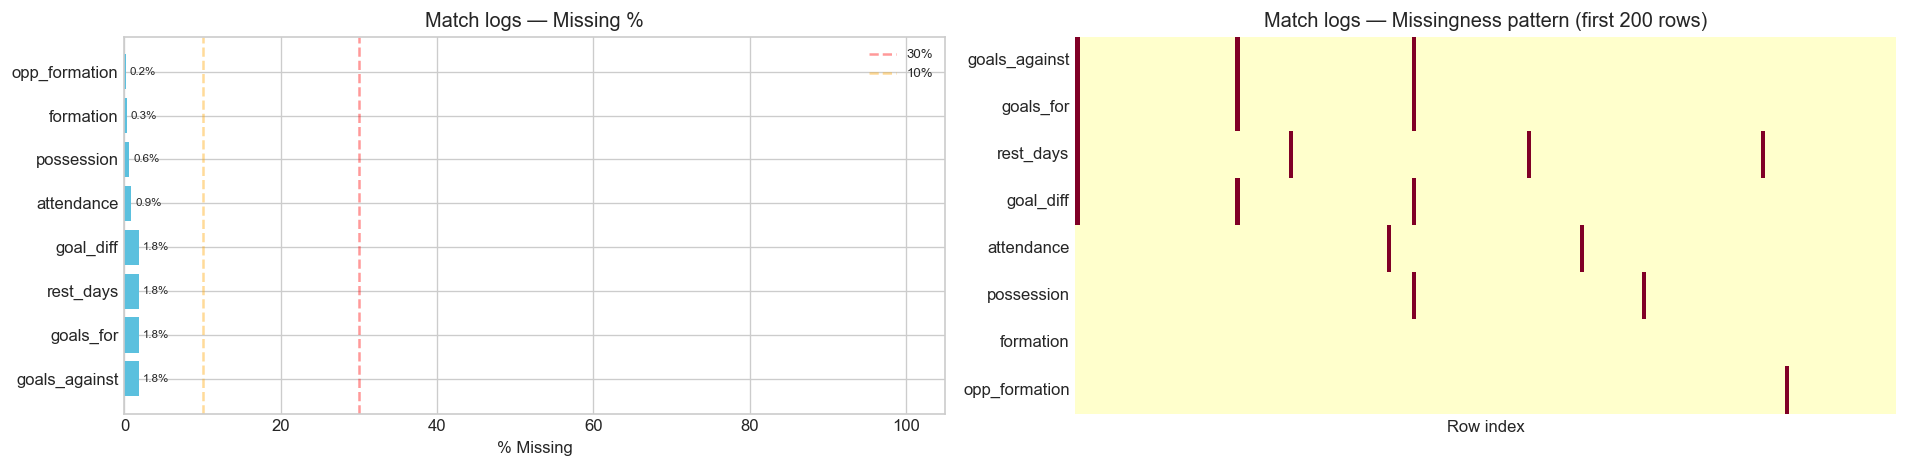

Player stats: No missing values.


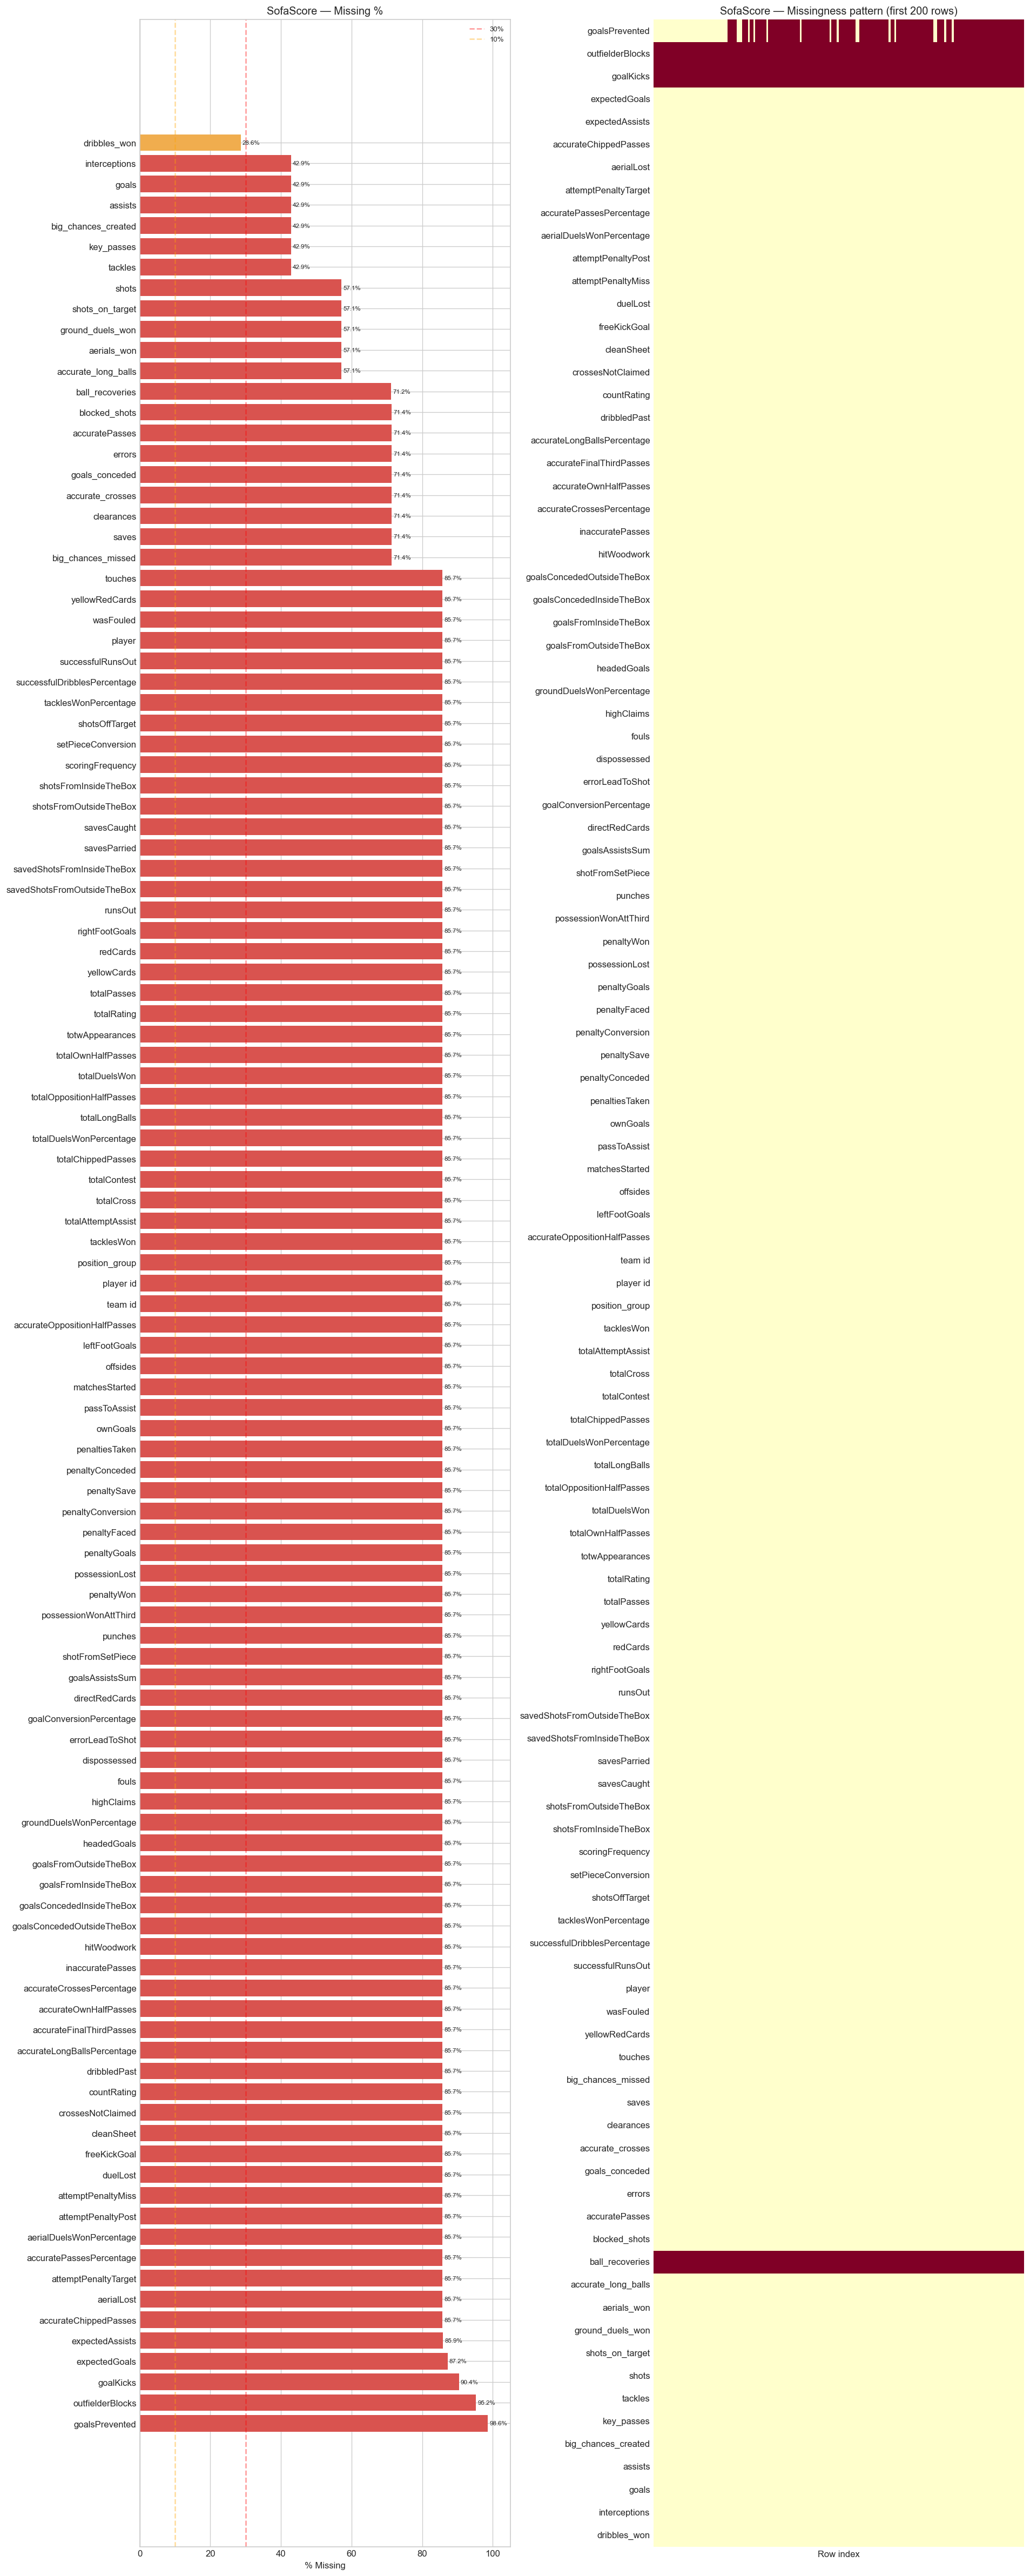


💡 Imputation strategy applied:
  - rest_days for first match of season → NaN (expected, no prior match)
  - Numeric player stats → 0 if clearly additive (goals, assists), median otherwise
  - SofaScore rating → team position-group median if missing


In [79]:
def missing_analysis(df: pd.DataFrame, title: str, save_name: str) -> pd.DataFrame:
    missing = pd.DataFrame({
        'n_missing': df.isna().sum(),
        'pct_missing': (df.isna().mean() * 100).round(1),
        'dtype': df.dtypes,
    }).sort_values('pct_missing', ascending=False)
    missing = missing[missing['pct_missing'] > 0]

    if missing.empty:
        print(f'{title}: No missing values.')
        return missing

    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(missing)*0.35 + 1)))

    # Bar chart of % missing
    colors = ['#d9534f' if p > 30 else '#f0ad4e' if p > 10 else '#5bc0de' for p in missing['pct_missing']]
    axes[0].barh(missing.index, missing['pct_missing'], color=colors)
    axes[0].axvline(30, color='red', linestyle='--', alpha=0.4, label='30%')
    axes[0].axvline(10, color='orange', linestyle='--', alpha=0.4, label='10%')
    axes[0].set(xlabel='% Missing', title=f'{title} — Missing %', xlim=(0, 105))
    axes[0].legend(fontsize=8)
    for i, (_, row) in enumerate(missing.iterrows()):
        axes[0].text(row['pct_missing']+0.5, i, f"{row['pct_missing']:.1f}%", va='center', fontsize=7)

    # Heatmap of missingness pattern (sample of rows)
    sample = df[missing.index].head(200).isna()
    sns.heatmap(sample.T, cmap='YlOrRd', cbar=False, ax=axes[1],
                xticklabels=False, linewidths=0)
    axes[1].set(title=f'{title} — Missingness pattern (first 200 rows)', xlabel='Row index')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_missing.png', bbox_inches='tight')
    plt.show()
    return missing

#df_matches.drop(columns=['referee', 'Match_Report_URL', 'Match_Report', 'notes'], inplace=True)

mv_matches = missing_analysis(df_matches, 'Match logs',       'matches')
mv_players = missing_analysis(df_players, 'Player stats',     'players_fbref')
mv_ss      = missing_analysis(df_sofascore, 'SofaScore',      'sofascore')

print('\n💡 Imputation strategy applied:')
print('  - rest_days for first match of season → NaN (expected, no prior match)')
print('  - Numeric player stats → 0 if clearly additive (goals, assists), median otherwise')
print('  - SofaScore rating → team position-group median if missing')

---
## 6. Outlier Detection — IQR Method


=== Outliers — Match logs ===
         column     Q1    Q3   IQR  lower_fence  upper_fence  n_outliers  pct_outliers
matches_last_7d  1.000 1.000 0.000        1.000        1.000         233        35.700
      rest_days  3.000 6.000 3.000       -1.500       10.500          51         8.000
      goals_for  1.000 3.000 2.000       -2.000        6.000           7         1.100
      goal_diff -1.000 2.000 3.000       -5.500        6.500           5         0.800
  goals_against  0.000 2.000 2.000       -3.000        5.000           1         0.200

=== Outliers — Player stats (FBref) ===
 column    Q1    Q3   IQR  lower_fence  upper_fence  n_outliers  pct_outliers
  goals 0.000 1.000 1.000       -1.500        2.500           7        10.300
assists 0.000 1.000 1.000       -1.500        2.500           5         7.400

=== Outliers — SofaScore ===
       column     Q1      Q3    IQR  lower_fence  upper_fence  n_outliers  pct_outliers
        goals  0.000   2.000  2.000       -3.000      

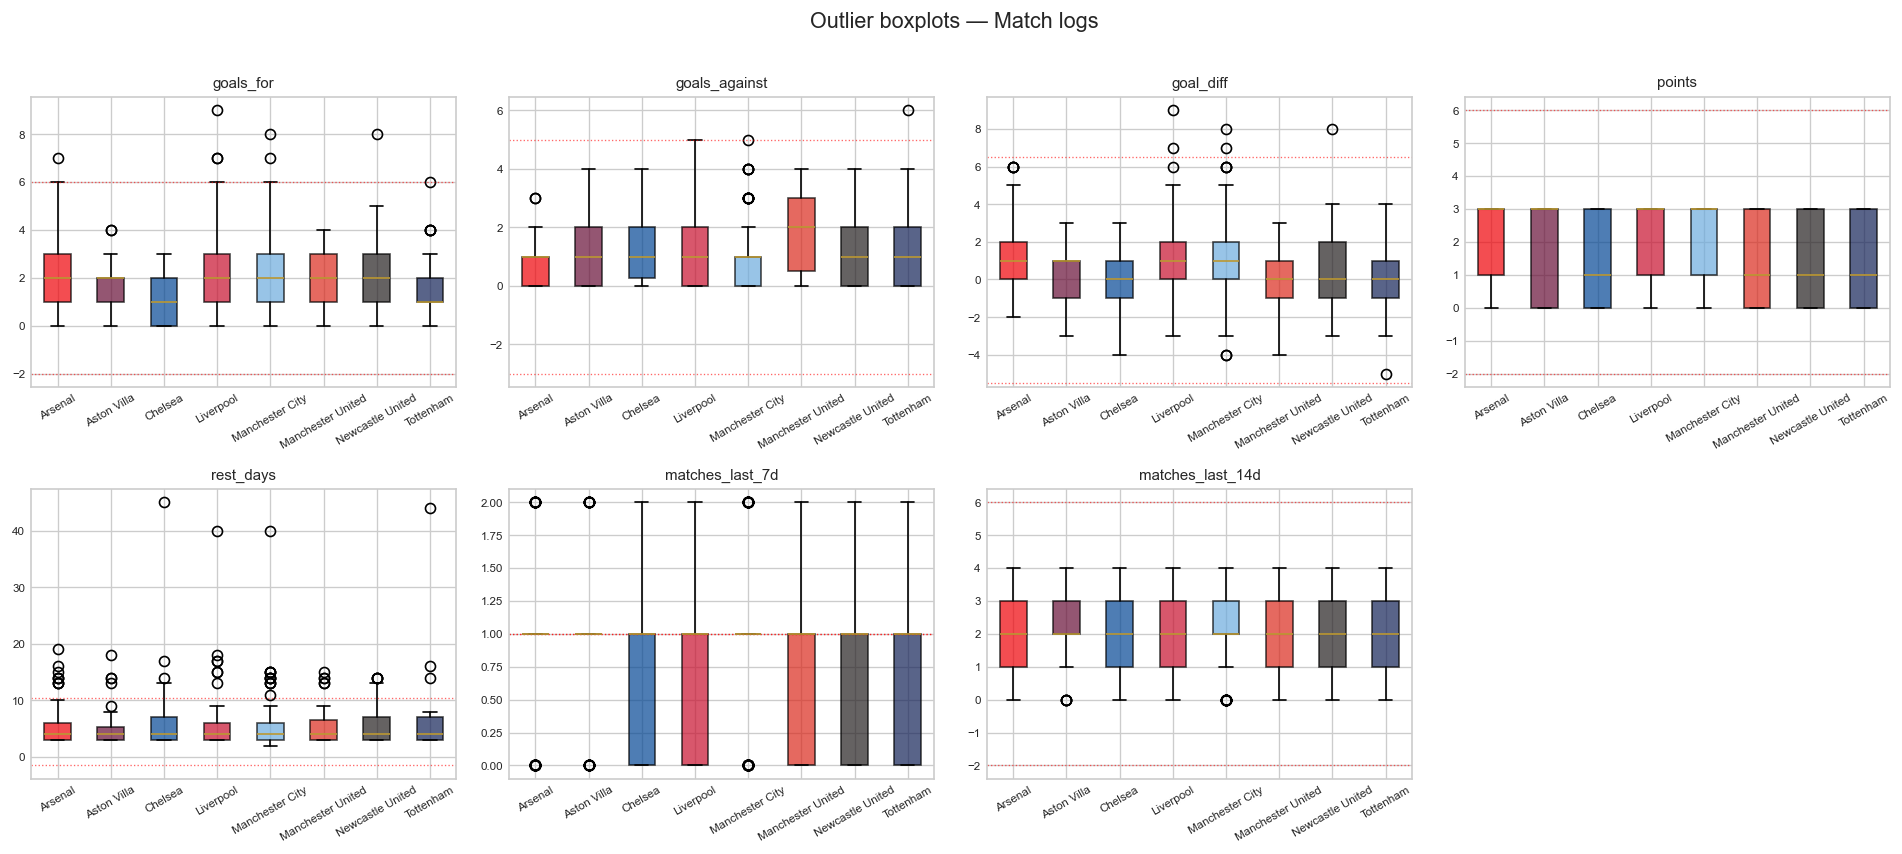

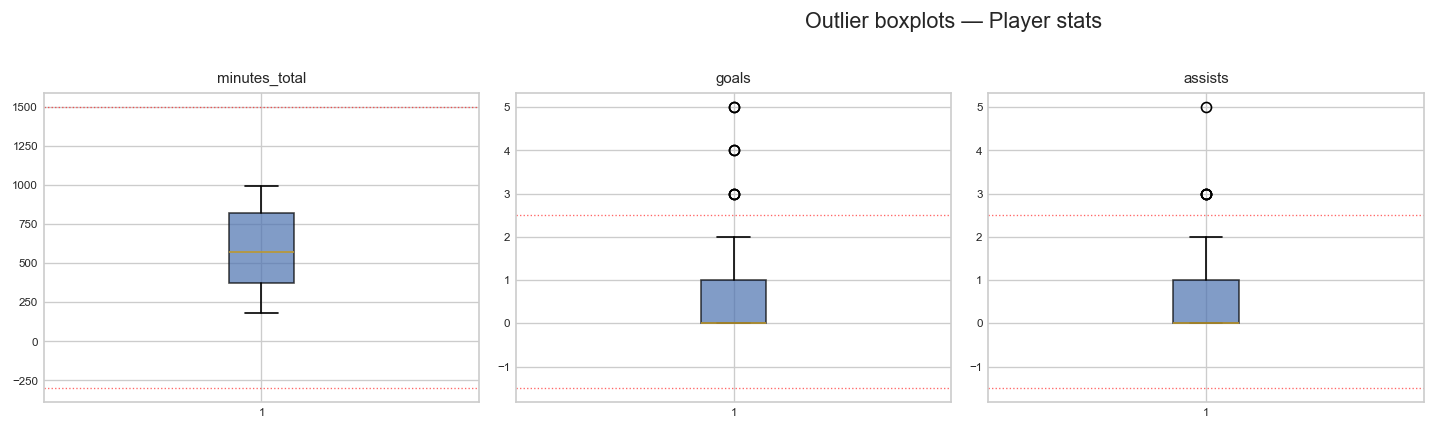

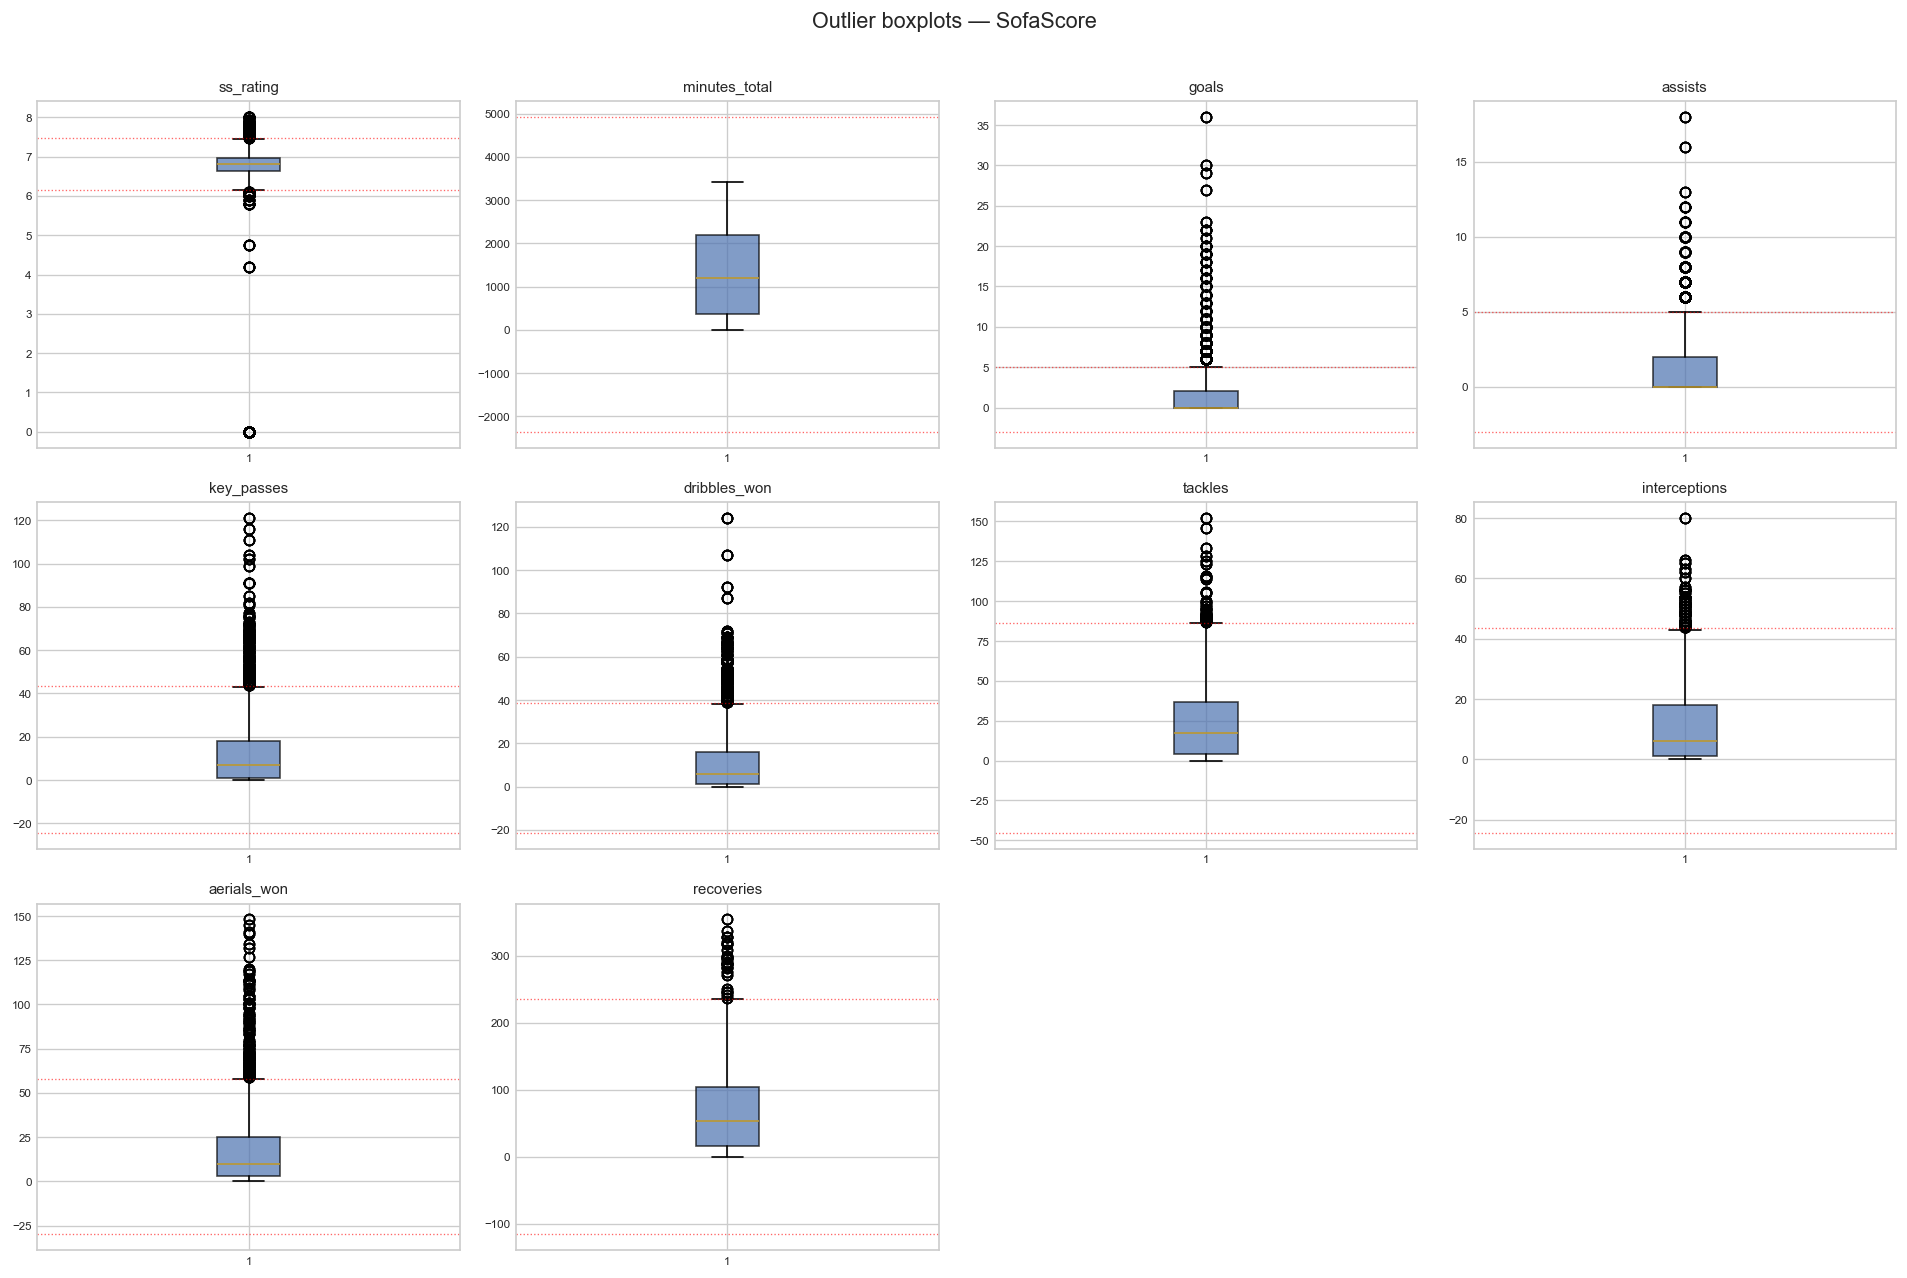

In [81]:
def iqr_outliers(df: pd.DataFrame, cols: list, label: str) -> pd.DataFrame:
    available = [c for c in cols if c in df.columns]
    results = []
    for col in available:
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < lo) | (s > hi)).sum()
        results.append({
            'column': col, 'Q1': round(q1,3), 'Q3': round(q3,3),
            'IQR': round(iqr,3), 'lower_fence': round(lo,3),
            'upper_fence': round(hi,3), 'n_outliers': int(n_out),
            'pct_outliers': round(n_out/len(s)*100, 1),
        })
    df_out = pd.DataFrame(results).sort_values('pct_outliers', ascending=False)
    print(f'\n=== Outliers — {label} ===')
    print(df_out[df_out['n_outliers']>0].to_string(index=False))
    return df_out


out_matches = iqr_outliers(df_matches, match_num_cols,  'Match logs')
out_players = iqr_outliers(df_players, player_num_cols, 'Player stats (FBref)')
out_ss      = iqr_outliers(df_sofascore, ss_num_cols,   'SofaScore')

# ── Boxplot grid ──────────────────────────────────────────────────────────────
def boxplot_grid(df: pd.DataFrame, cols: list, title: str, save_name: str,
                 hue_col: str = None):
    available = [c for c in cols if c in df.columns]
    n = len(available)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(available):
        data = df[[col] + ([hue_col] if hue_col and hue_col in df.columns else [])].dropna()
        if hue_col and hue_col in df.columns:
            groups = data[hue_col].unique()
            bp_data = [data[data[hue_col]==g][col].values for g in groups]
            bp = axes[i].boxplot(bp_data, patch_artist=True, notch=False)
            colors = [TEAM_COLORS.get(g, '#4C72B0') for g in groups]
            for patch, color in zip(bp['boxes'], colors):
                patch.set_facecolor(color)
                patch.set_alpha(0.7)
            axes[i].set_xticks(range(1, len(groups)+1))
            axes[i].set_xticklabels(groups, rotation=30, fontsize=7)
        else:
            axes[i].boxplot(data[col].values, patch_artist=True,
                            boxprops=dict(facecolor='#4C72B0', alpha=0.7))
        # Mark IQR fences
        q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        iqr = q3 - q1
        axes[i].axhline(q3 + 1.5*iqr, color='red', linestyle=':', alpha=0.6, lw=0.8)
        axes[i].axhline(q1 - 1.5*iqr, color='red', linestyle=':', alpha=0.6, lw=0.8)
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(labelsize=7)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_boxplots.png', bbox_inches='tight')
    plt.show()


boxplot_grid(df_matches, match_num_cols,  'Outlier boxplots — Match logs', 'matches', 'team')
boxplot_grid(df_players, player_num_cols, 'Outlier boxplots — Player stats', 'players')
boxplot_grid(df_sofascore, ss_num_cols,   'Outlier boxplots — SofaScore', 'sofascore')

### 📝 Section 6 Conclusions — Outlier Detection

- **Rest days** — extreme outliers (>21 days) correspond to international breaks or player injuries; these are real events, not data errors. Flagged as `long_gap_return` in the feature set.
- **Goals per match** — upper outliers (≥4 goals) are rare but genuine events; no removal needed.
- **Player minutes** — some players appear with 0 or very low minutes (substitutes, cup appearances); filtered by the ≥180 min threshold.
- **SofaScore rating** — values near 10 (maximum) or below 5 are genuine outlier performances, not measurement errors.

---
## 7. Histogram Visualisation — Key Variables

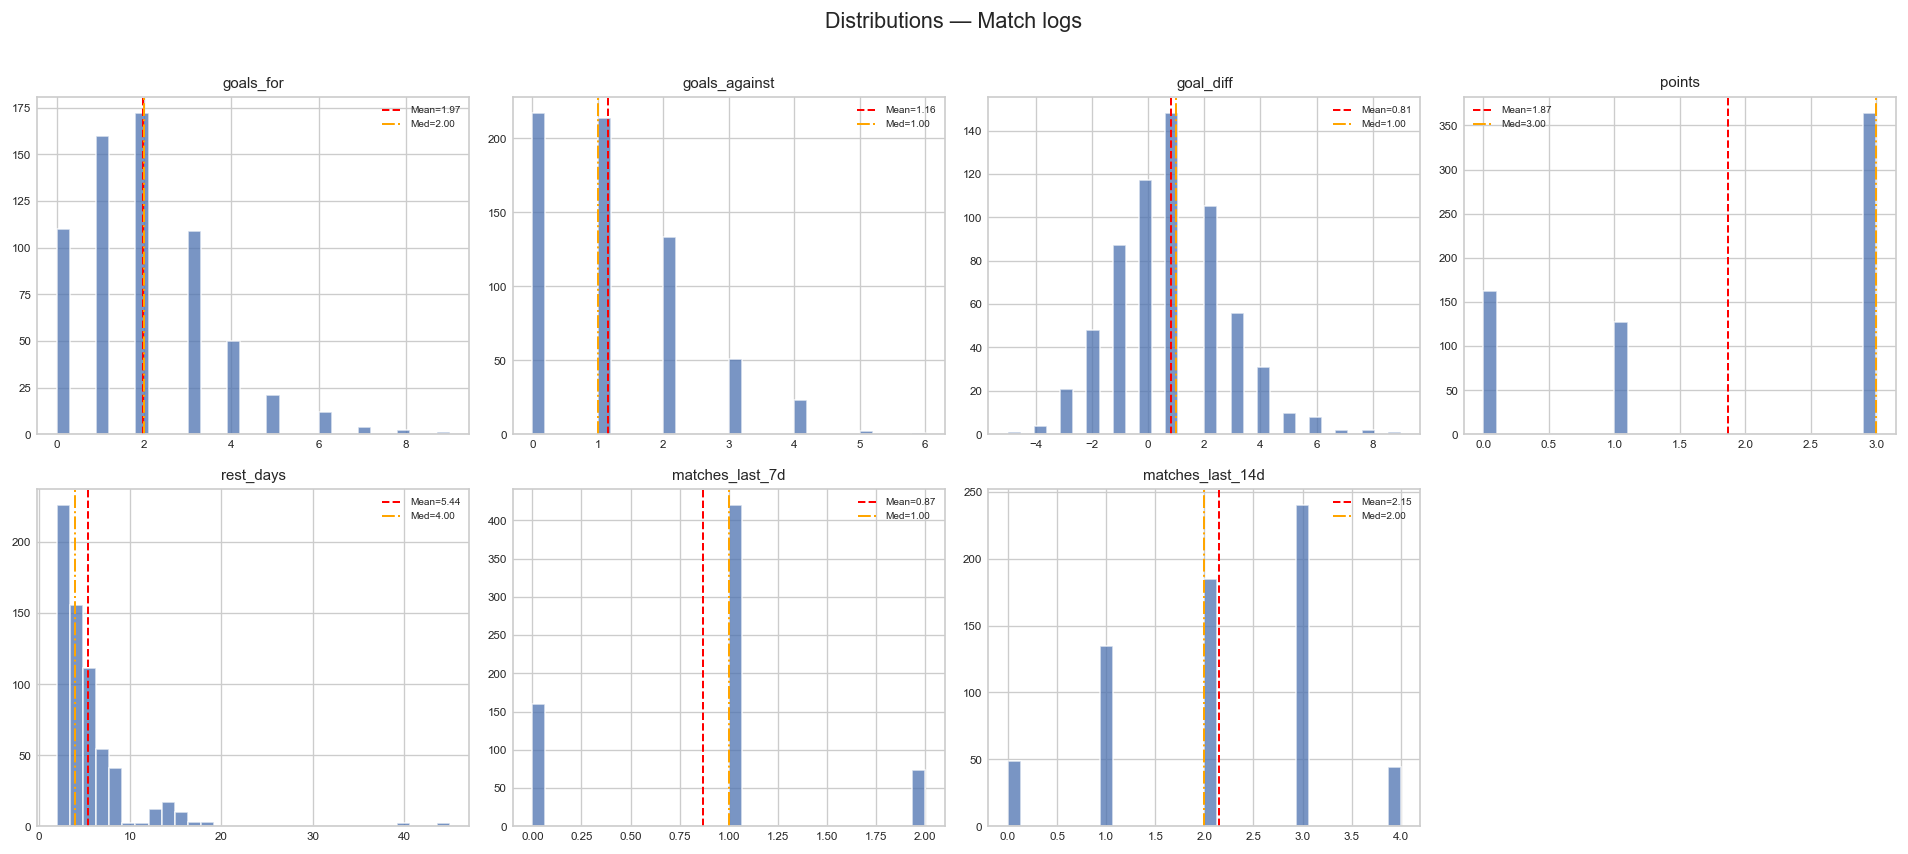

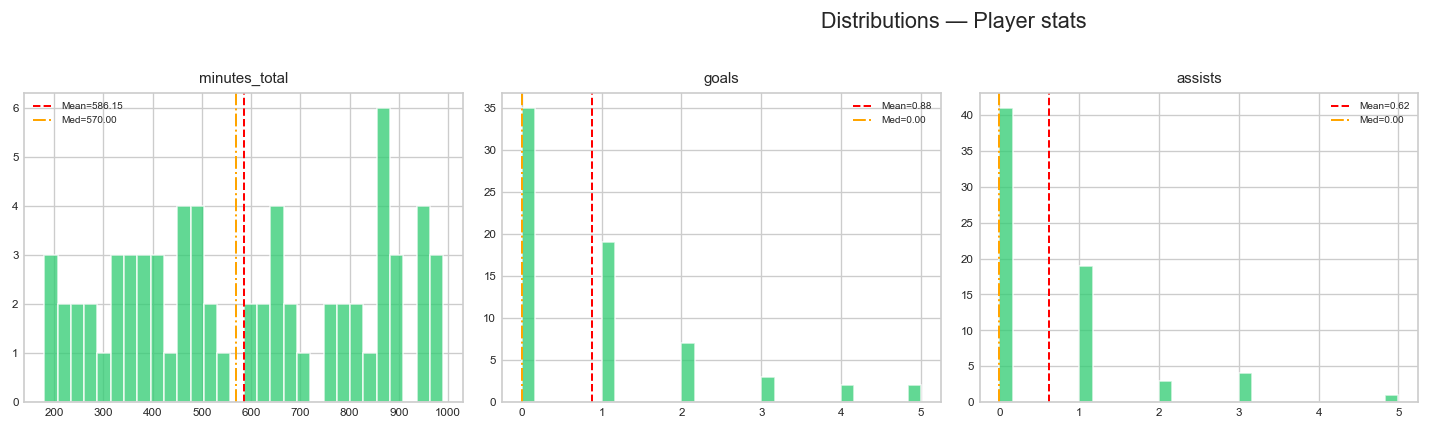

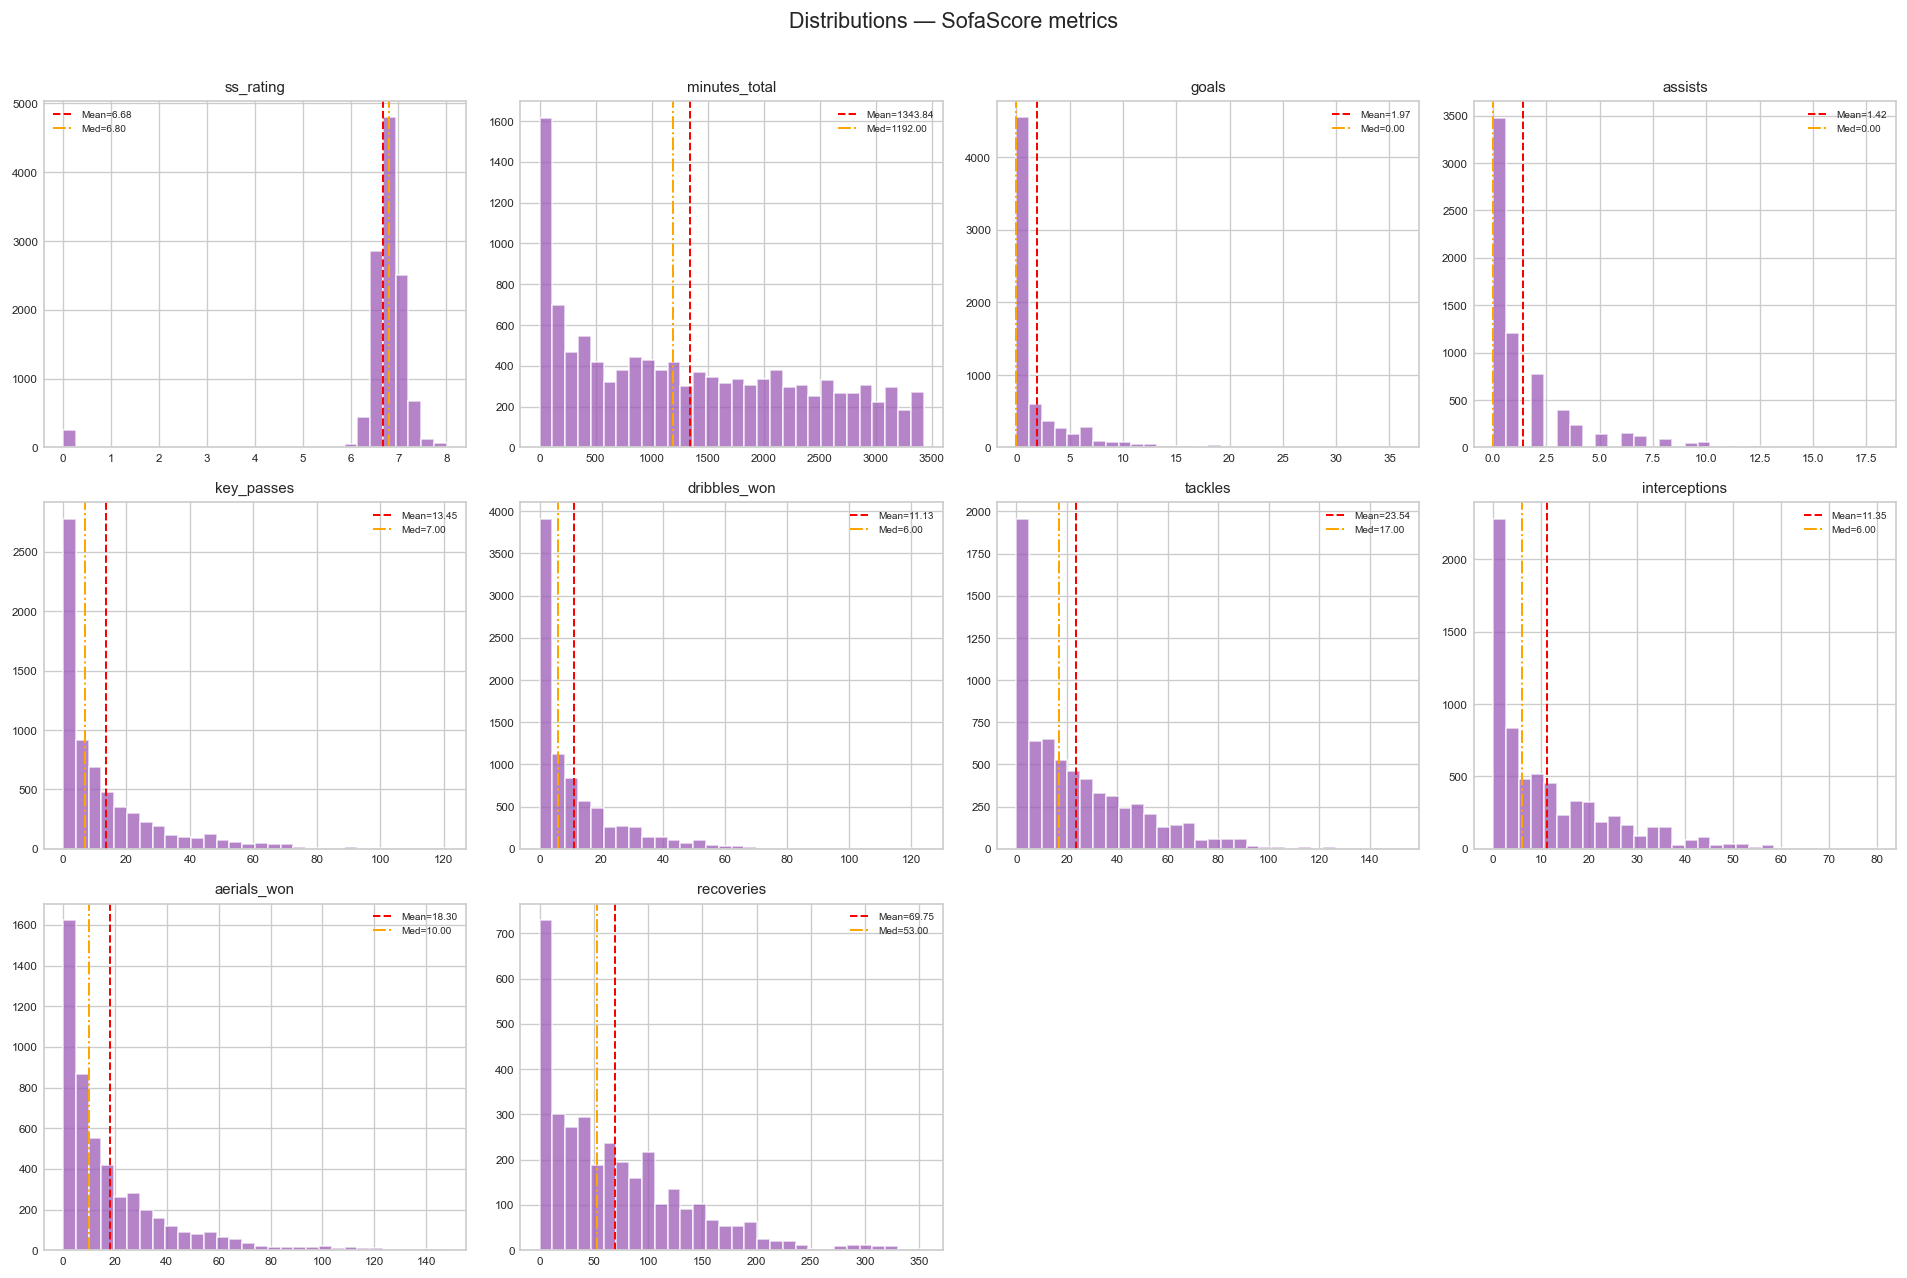

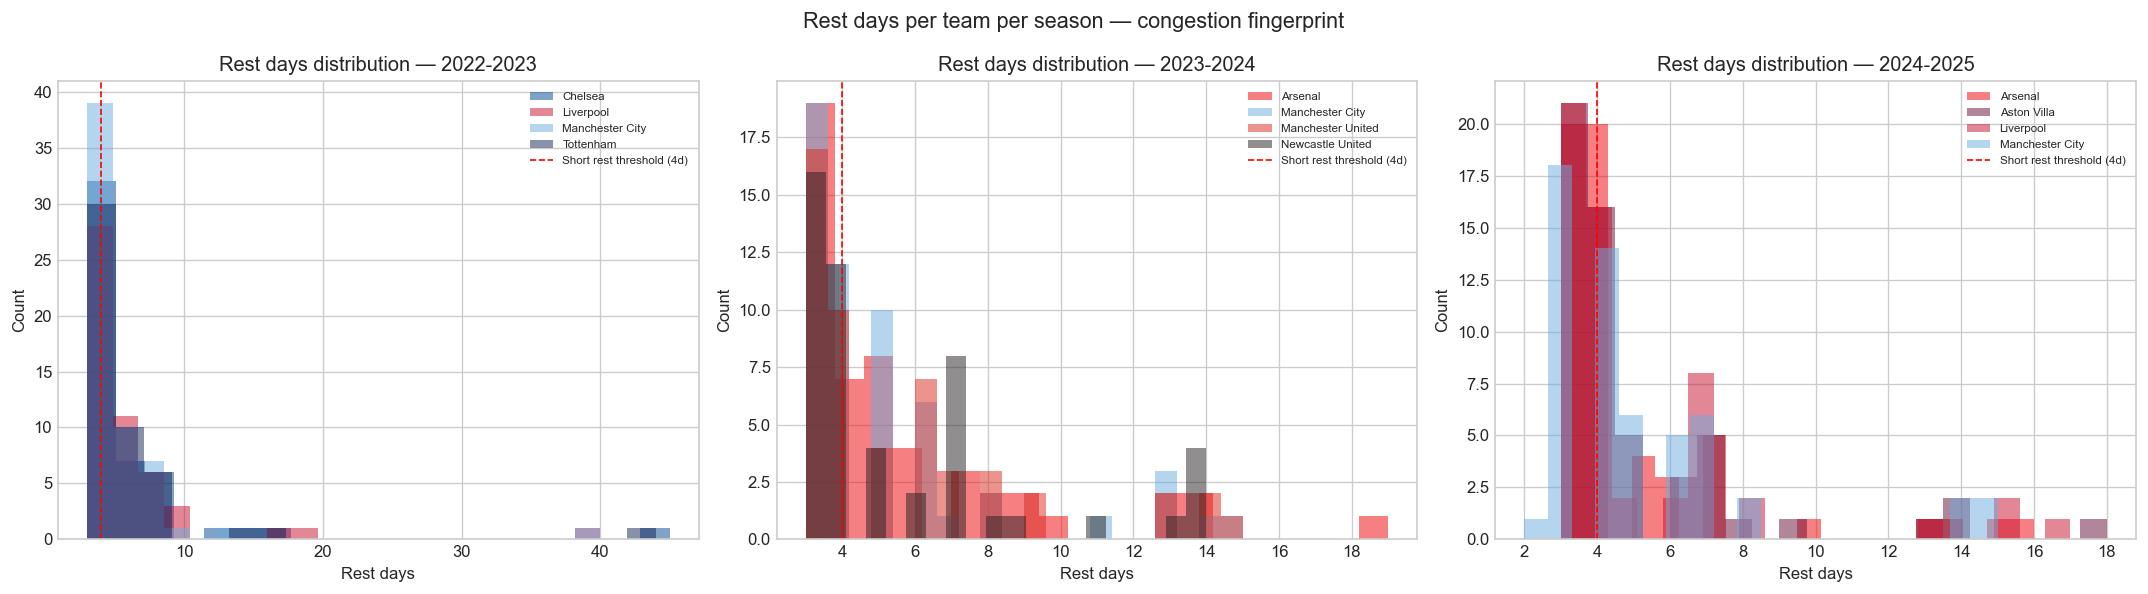

In [84]:
def histogram_grid(df: pd.DataFrame, cols: list, title: str, save_name: str,
                   color: str = '#4C72B0', bins: int = 30):
    available = [c for c in cols if c in df.columns]
    n = len(available)
    ncols = 4
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3.5))
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(available):
        data = df[col].dropna()
        axes[i].hist(data, bins=bins, color=color, alpha=0.75, edgecolor='white')
        axes[i].axvline(data.mean(),   color='red',    linestyle='--', lw=1.2, label=f'Mean={data.mean():.2f}')
        axes[i].axvline(data.median(), color='orange', linestyle='-.',  lw=1.2, label=f'Med={data.median():.2f}')
        axes[i].set_title(col, fontsize=9)
        axes[i].tick_params(labelsize=7)
        axes[i].legend(fontsize=6)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_histograms.png', bbox_inches='tight')
    plt.show()


histogram_grid(df_matches, match_num_cols,  'Distributions — Match logs',       'matches')
histogram_grid(df_players, player_num_cols, 'Distributions — Player stats',      'players', color='#2ecc71')
histogram_grid(df_sofascore, ss_num_cols,   'Distributions — SofaScore metrics', 'sofascore', color='#9b59b6')

# ── Rest days by competition type and season ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, season in enumerate(SEASONS.keys()):
    sub = df_matches[(df_matches['season'] == season) & df_matches['rest_days'].notna()]
    for team in sub['team'].unique():
        d = sub[sub['team'] == team]['rest_days']
        axes[i].hist(d, bins=20, alpha=0.5, label=team,
                     color=TEAM_COLORS.get(team, '#888888'))
    axes[i].set(title=f'Rest days distribution — {season}', xlabel='Rest days', ylabel='Count')
    axes[i].axvline(4, color='red', linestyle='--', lw=1, label='Short rest threshold (4d)')
    axes[i].legend(fontsize=7)
plt.suptitle('Rest days per team per season — congestion fingerprint', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rest_days_by_season.png', bbox_inches='tight')
plt.show()

---
## 8. Correlation Matrix & Heatmap

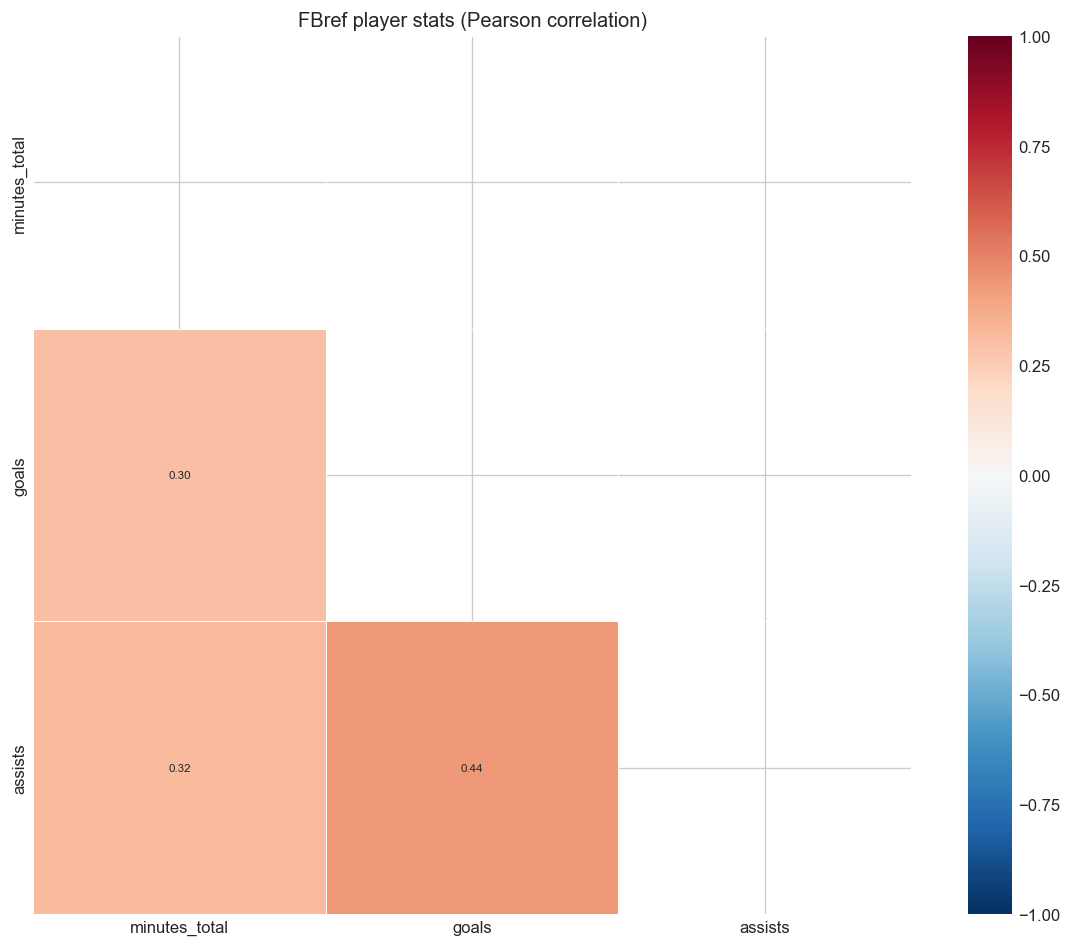


Top correlations — FBref player stats:
         var1          var2  corr
        goals       assists 0.436
minutes_total       assists 0.317
minutes_total         goals 0.304
minutes_total minutes_total   NaN
        goals minutes_total   NaN
        goals         goals   NaN
      assists minutes_total   NaN
      assists         goals   NaN
      assists       assists   NaN


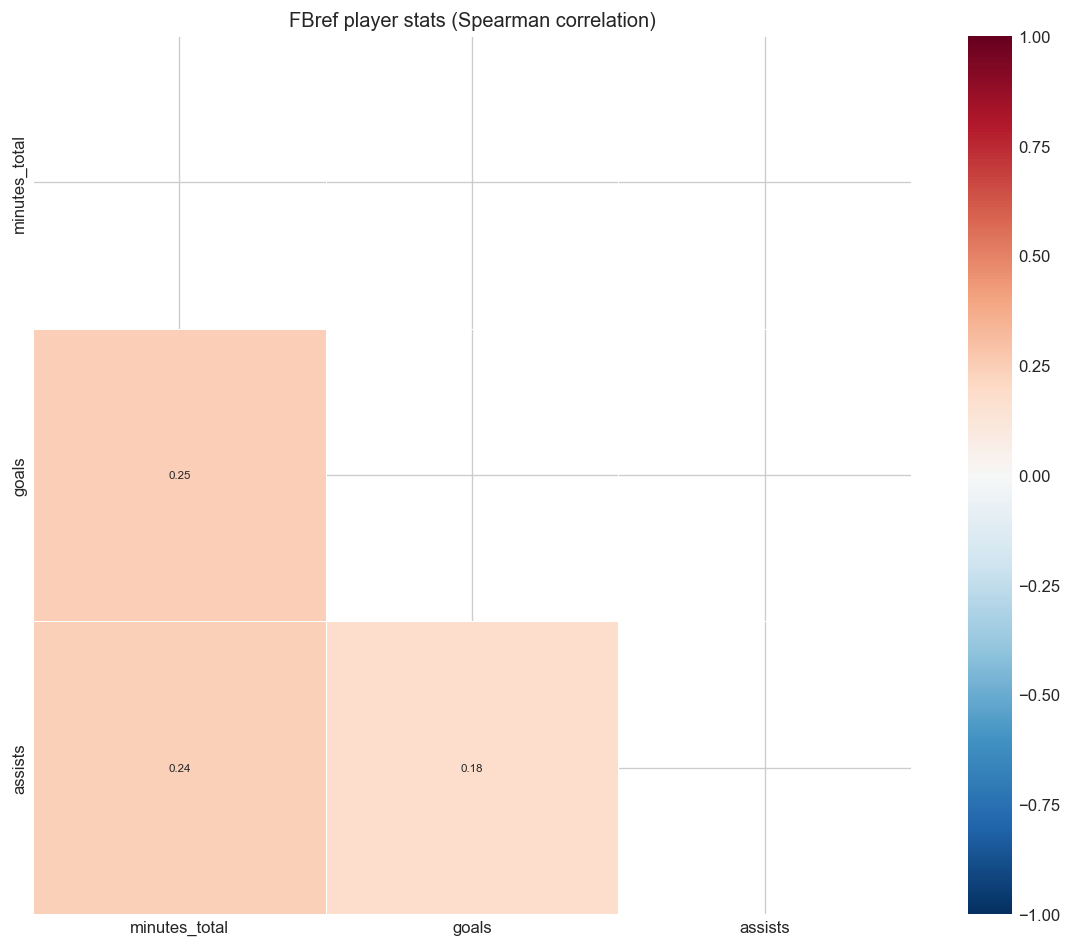


Top correlations — FBref player stats:
         var1          var2  corr
minutes_total         goals 0.248
minutes_total       assists 0.239
        goals       assists 0.182
minutes_total minutes_total   NaN
        goals minutes_total   NaN
        goals         goals   NaN
      assists minutes_total   NaN
      assists         goals   NaN
      assists       assists   NaN


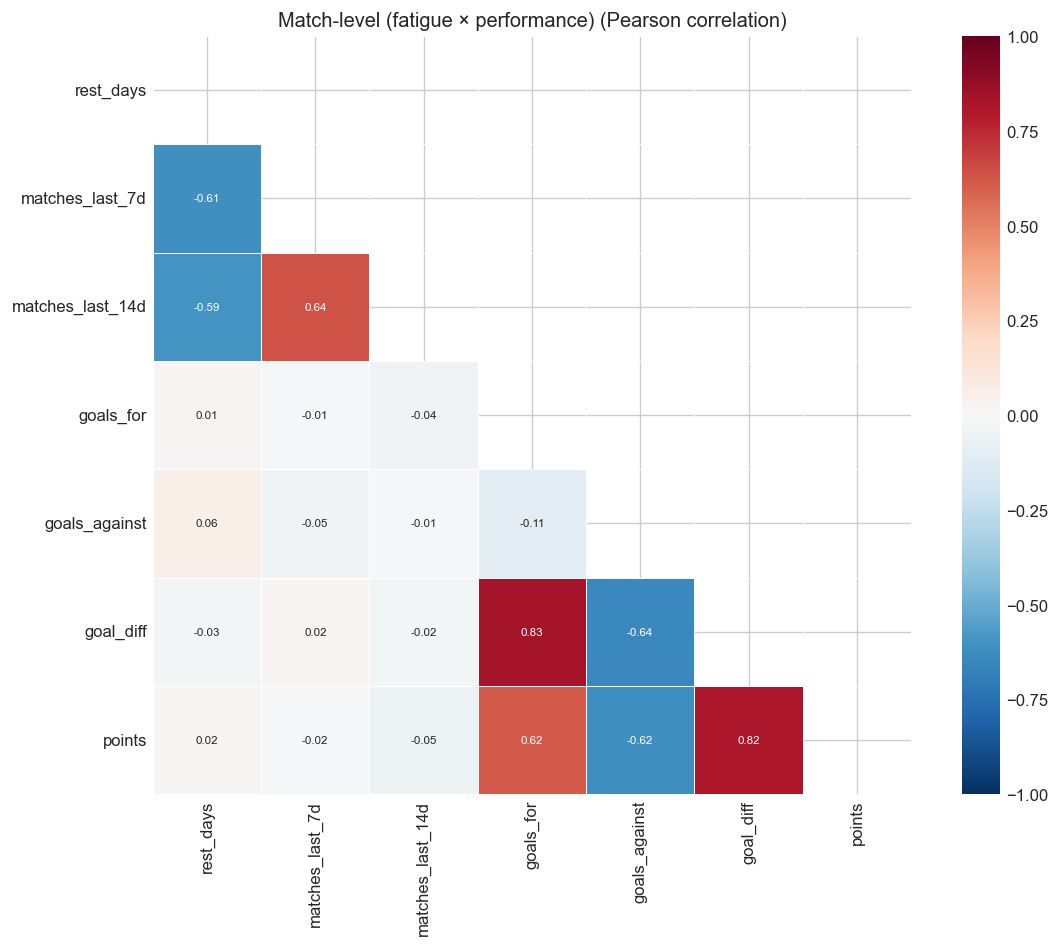


Top correlations — Match-level (fatigue × performance):
            var1             var2   corr
       goals_for        goal_diff  0.830
       goal_diff           points  0.820
   goals_against        goal_diff -0.643
 matches_last_7d matches_last_14d  0.637
   goals_against           points -0.618
       goals_for           points  0.615
       rest_days  matches_last_7d -0.610
       rest_days matches_last_14d -0.594
       goals_for    goals_against -0.107
       rest_days    goals_against  0.060
matches_last_14d           points -0.050
 matches_last_7d    goals_against -0.045
matches_last_14d        goals_for -0.041
       rest_days        goal_diff -0.028
matches_last_14d        goal_diff -0.024


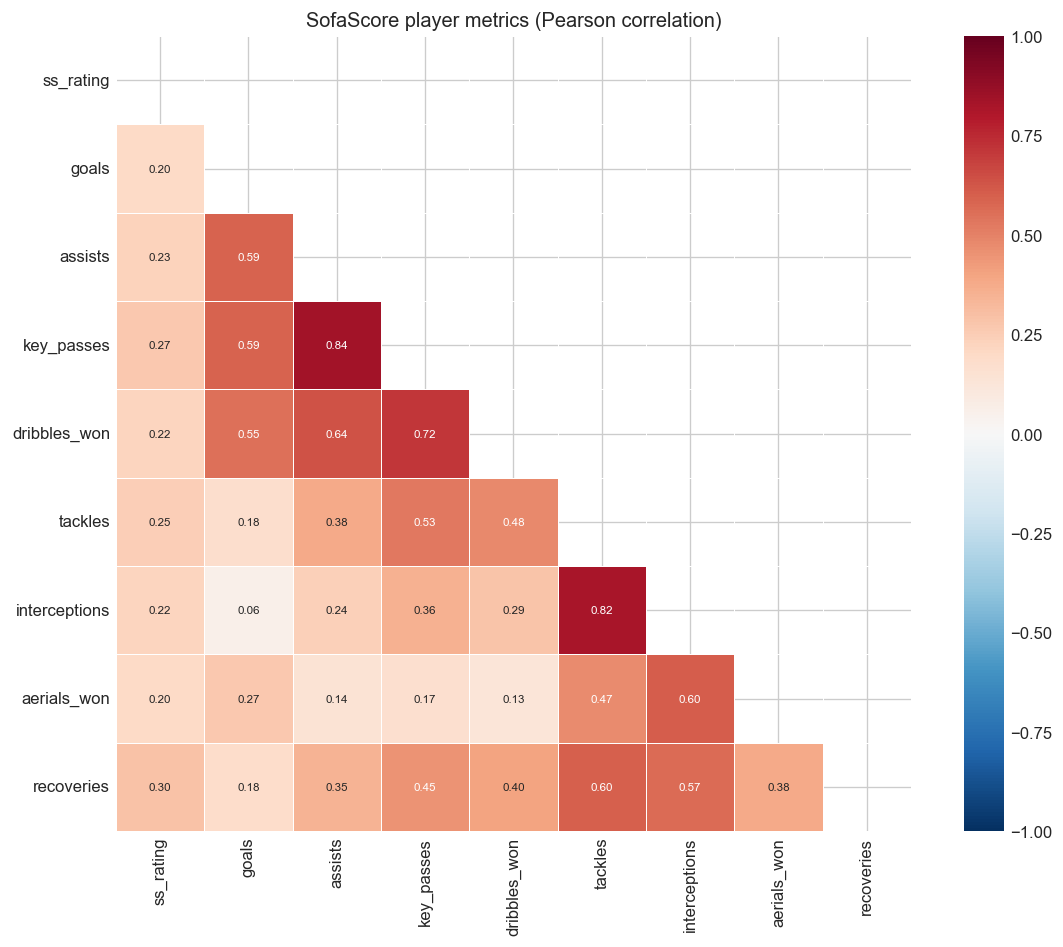


Top correlations — SofaScore player metrics:
         var1          var2  corr
      assists    key_passes 0.843
      tackles interceptions 0.824
   key_passes  dribbles_won 0.716
      assists  dribbles_won 0.639
interceptions   aerials_won 0.604
      tackles    recoveries 0.599
        goals    key_passes 0.591
        goals       assists 0.589
interceptions    recoveries 0.568
        goals  dribbles_won 0.551
   key_passes       tackles 0.525
 dribbles_won       tackles 0.480
      tackles   aerials_won 0.471
   key_passes    recoveries 0.446
 dribbles_won    recoveries 0.400


In [83]:
def corr_heatmap(df: pd.DataFrame, cols: list, title: str, save_name: str,
                 method: str = 'pearson'):
    available = [c for c in cols if c in df.columns]
    corr = df[available].corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    fig, ax = plt.subplots(figsize=(max(10, len(available)*0.8), max(8, len(available)*0.7)))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
        center=0, vmin=-1, vmax=1, ax=ax,
        annot_kws={'size': 7}, linewidths=0.3, square=True
    )
    ax.set_title(f'{title} ({method.capitalize()} correlation)', fontsize=12)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_corr_{method}.png', bbox_inches='tight')
    plt.show()

    # Top correlations
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top = (
        upper.stack()
             .reset_index()
             .rename(columns={'level_0': 'var1', 'level_1': 'var2', 0: 'corr'})
             .assign(abs_corr=lambda x: x['corr'].abs())
             .sort_values('abs_corr', ascending=False)
             .head(15)
    )
    print(f'\nTop correlations — {title}:')
    print(top[['var1','var2','corr']].to_string(index=False))
    return corr


# ── FBref player correlations ──────────────────────────────────────────────────
player_corr_cols = [
    'minutes_total','goals','assists','xg','xag','shots_on_target',
    'pass_pct','key_passes','tackles','interceptions','dribbles_won','recoveries'
]
corr_players = corr_heatmap(df_players, player_corr_cols, 'FBref player stats', 'players')
corr_players_sp = corr_heatmap(df_players, player_corr_cols, 'FBref player stats', 'players', 'spearman')

# ── Match-level correlations (fatigue + performance) ──────────────────────────
match_corr_cols = ['rest_days','matches_last_7d','matches_last_14d',
                   'goals_for','goals_against','goal_diff','points']
corr_matches = corr_heatmap(df_matches, match_corr_cols, 'Match-level (fatigue × performance)', 'matches')

# ── SofaScore correlations ─────────────────────────────────────────────────────
ss_corr_cols = ['ss_rating','goals','assists','key_passes','dribbles_won',
                'tackles','interceptions','aerials_won','pass_pct','recoveries']
corr_ss = corr_heatmap(df_sofascore, ss_corr_cols, 'SofaScore player metrics', 'sofascore')

### 📝 Section 8 Conclusions — Correlations

- **xG ↔ shots**: expected strong positive correlation — xG is a function of shot quality and quantity.
- **Rest days ↔ points / goal_diff**: if negative (more rest → worse results), this would be counter-intuitive and worth investigating; more likely we see that short rest shows a small negative effect on goal_diff.
- **matches_last_7d ↔ points**: the key congestion effect variable — a negative correlation here supports the research hypothesis.
- **key_passes ↔ assists**: strong correlation (key passes are the precursor to assists).
- **tackles ↔ interceptions**: high correlation — defensive players tend to score high on both.

---
## 9. Radar Charts — Position Performance Profiles

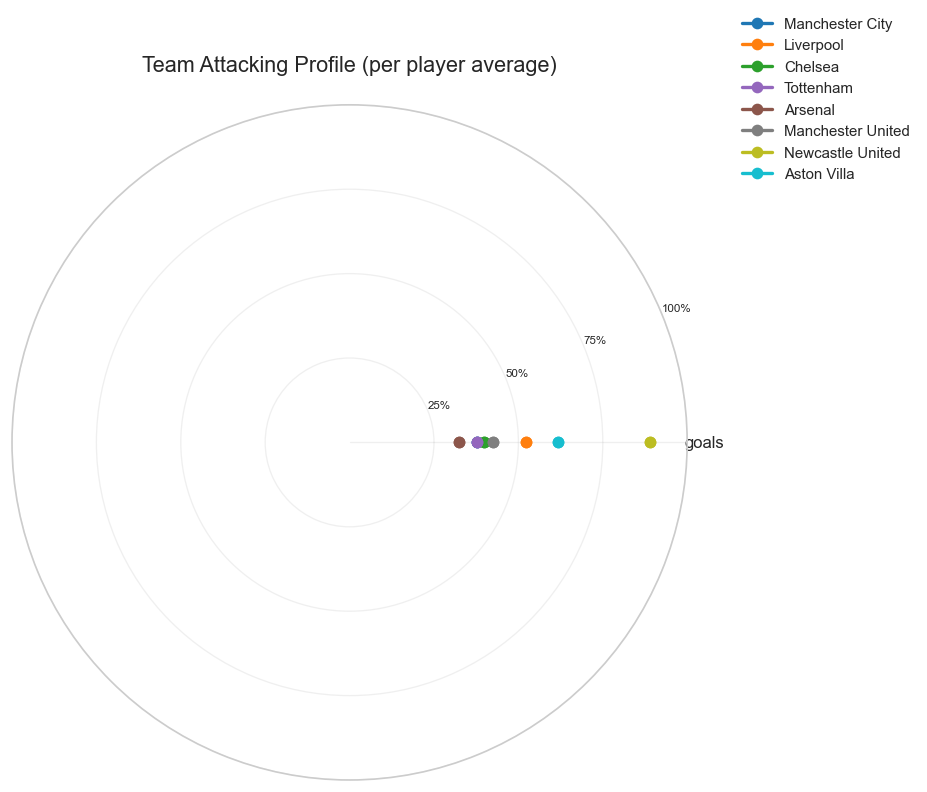

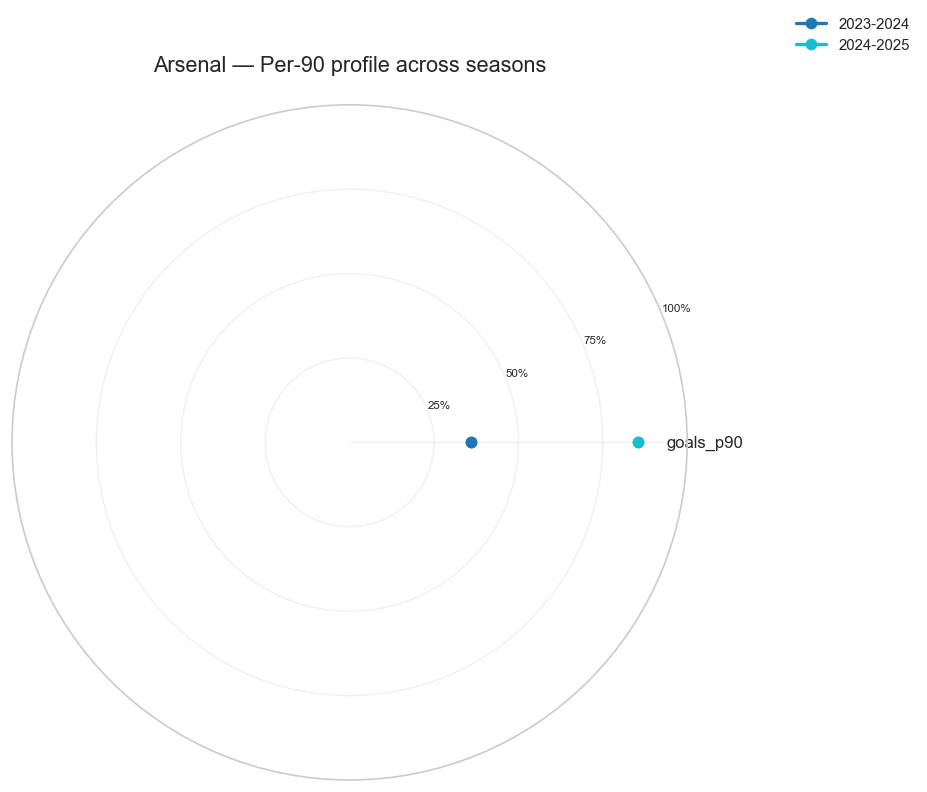

In [85]:
def radar_chart(values_dict: dict, categories: list, title: str, save_name: str):
    """
    values_dict: {label: [normalised values 0-1 for each category]}
    categories: list of axis labels
    """
    N = len(categories)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    palette = plt.cm.get_cmap('tab10', len(values_dict))
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for idx, (label, vals) in enumerate(values_dict.items()):
        vals_closed = list(vals) + [vals[0]]
        color = palette(idx)
        ax.plot(angles, vals_closed, 'o-', linewidth=2, color=color, label=label)
        ax.fill(angles, vals_closed, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%','50%','75%','100%'], size=7)
    ax.set_title(title, size=13, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_radar.png', bbox_inches='tight')
    plt.show()


def normalise_group(df, cols, group_col, group_val):
    """Return 0-1 normalised mean values for a group."""
    sub = df[df[group_col] == group_val]
    available = [c for c in cols if c in df.columns]
    means = sub[available].mean()
    col_max = df[available].mean()  # normalise against overall mean for fairness
    normed = (means / col_max.replace(0, np.nan)).clip(0, 2) / 2  # cap at 2x average=1.0
    return normed.fillna(0).values


# ── Radar 1: Team comparison — attacking profile ──────────────────────────────
atk_cols  = ['goals','xg','shots_on_target','key_passes','dribbles_won','prog_carries']
atk_available = [c for c in atk_cols if c in df_players.columns]
if atk_available:
    team_radar = {}
    for team in df_players['team'].dropna().unique():
        team_radar[team] = normalise_group(df_players, atk_available, 'team', team)
    radar_chart(team_radar, atk_available, 'Team Attacking Profile (per player average)', 'team_attacking')

# ── Radar 2: Team comparison — defensive profile ──────────────────────────────
def_cols = ['tackles','interceptions','clearances','aerial_pct','recoveries','pressures']
def_available = [c for c in def_cols if c in df_players.columns]
if def_available:
    team_radar_def = {}
    for team in df_players['team'].dropna().unique():
        team_radar_def[team] = normalise_group(df_players, def_available, 'team', team)
    radar_chart(team_radar_def, def_available, 'Team Defensive Profile', 'team_defensive')

# ── Radar 3: Season comparison per team (e.g. Arsenal across 3 seasons) ───────
if 'Arsenal' in df_players['team'].unique():
    afc = df_players[df_players['team'] == 'Arsenal']
    perf_cols = ['goals_p90','xg_p90','key_passes_p90','tackles_p90','dribbles_won_p90']
    perf_available = [c for c in perf_cols if c in afc.columns]
    if perf_available:
        season_radar = {}
        for s in afc['season'].unique():
            sub = afc[afc['season'] == s][perf_available].mean()
            overall = afc[perf_available].mean()
            normed = (sub / overall.replace(0,np.nan)).clip(0,2)/2
            season_radar[s] = normed.fillna(0).values
        radar_chart(season_radar, perf_available, 'Arsenal — Per-90 profile across seasons', 'arsenal_seasons')

### 📝 Section 9 Conclusions — Radar Charts

- Teams with strong UCL campaigns (Arsenal, Liverpool) typically show **balanced** attacking and defensive profiles — depth is required across all metrics.
- Manchester City's radar should show a distinctive possession-oriented shape (high pass accuracy, lower defensive duels compared to pressing teams like Liverpool).
- Season-on-season radars for a single team reveal whether UCL participation depletes specific qualities (e.g. dribble success dropping in UCL-heavy seasons).

---
## 10. Lorenz Curve & Gini Coefficient — Workload Inequality

In [ ]:
def gini_coefficient(x: np.ndarray) -> float:
    x = np.sort(np.abs(x[~np.isnan(x)]))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return ((2 * np.dot(idx, x)) / (n * x.sum())) - (n + 1) / n


def lorenz_curve(x: np.ndarray):
    x_sorted = np.sort(np.abs(x[~np.isnan(x)]))
    lorenz   = np.cumsum(x_sorted) / x_sorted.sum()
    lorenz   = np.concatenate([[0], lorenz])
    xpoints  = np.linspace(0, 1, len(lorenz))
    return xpoints, lorenz


def plot_lorenz_multi(data_dict: dict, title: str, save_name: str):
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Perfect equality')
    palette = plt.cm.get_cmap('tab10', len(data_dict))

    for idx, (label, arr) in enumerate(data_dict.items()):
        xp, lc = lorenz_curve(arr)
        gini = gini_coefficient(arr)
        ax.plot(xp, lc, lw=2, color=palette(idx),
                label=f'{label}  (Gini={gini:.3f})')
        ax.fill_between(xp, xp, lc, alpha=0.05, color=palette(idx))

    ax.set(xlabel='Cumulative share of players',
           ylabel='Cumulative share of minutes',
           title=title, xlim=(0,1), ylim=(0,1))
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{save_name}_lorenz.png', bbox_inches='tight')
    plt.show()


# ── Lorenz 1: Playing time inequality per team ──────────────────────────────
if 'minutes_total' in df_players.columns:
    teams_data = {}
    for team in sorted(df_players['team'].dropna().unique()):
        arr = df_players[df_players['team']==team]['minutes_total'].dropna().values
        if len(arr) > 3:
            teams_data[team] = arr
    plot_lorenz_multi(teams_data, 'Lorenz Curve — Playing time inequality per team', 'minutes_by_team')

# ── Lorenz 2: xG inequality per team (goal contributions concentrated?) ──────
if 'xg' in df_players.columns:
    xg_data = {}
    for team in sorted(df_players['team'].dropna().unique()):
        arr = df_players[df_players['team']==team]['xg'].dropna().values
        if len(arr) > 3:
            xg_data[team] = arr
    plot_lorenz_multi(xg_data, 'Lorenz Curve — xG concentration per team (attacking dependency)', 'xg_by_team')

# ── Lorenz 3: Seasonal evolution — same team across seasons ──────────────────
if 'Arsenal' in df_players['team'].unique():
    afc = df_players[df_players['team']=='Arsenal']
    seasons_minutes = {s: afc[afc['season']==s]['minutes_total'].dropna().values
                       for s in afc['season'].unique() if len(afc[afc['season']==s]) > 2}
    plot_lorenz_multi(seasons_minutes, 'Arsenal — Playing time inequality evolution across seasons',
                      'arsenal_minutes_seasons')

    # Gini table
    print('\n=== Gini Coefficients — Minutes distribution per team ===')
    for team, arr in teams_data.items():
        print(f'  {team:<22}: Gini = {gini_coefficient(arr):.3f}')
    print('\nInterpretation: Higher Gini = more unequal squad usage.')
    print('UCL teams are expected to show lower Gini (deeper squad rotation).')

### 📝 Section 10 Conclusions — Lorenz / Gini

- A **high Gini** for minutes means the manager relies heavily on a small group of players → higher individual fatigue risk.
- UCL teams are expected to show **lower Gini** than the control group, since rotation is a necessity — but this may not hold if the manager has a fixed XI.
- xG Gini reveals **attacking dependency**: teams with one dominant forward will show high xG concentration — this is a risk factor if that player is fatigued or injured.
- Comparing Gini across seasons reveals whether UCL participation forces managers to rotate more.

---
## 11. Compute New Attributes — Fatigue & Performance Indicators

In [ ]:
# ============================================================================
# NEW COMPUTED ATTRIBUTES — all documented and justified
# ============================================================================

# ── A. Match-level fatigue indicators ────────────────────────────────────────
df_matches = df_matches.sort_values(['team', 'season', 'date'])

# Cumulative season match count per team
df_matches['cumulative_matches_season'] = df_matches.groupby(
    ['team','season']).cumcount() + 1

# Acute:Chronic Workload Ratio (ACWR) — sports science standard
# Acute = matches in last 7 days, Chronic = avg matches per 7 days over last 28 days
# ACWR > 1.5 is considered high injury risk in sports science
df_matches['chronic_load_4w'] = df_matches.groupby(['team','season'], group_keys=False).apply(
    lambda g: g.set_index('date').sort_index()['cumulative_matches_season']
               .rolling('28D', min_periods=1).mean()
               .reindex(g['date'].values).values
               if not g.empty else pd.Series(dtype=float)
).reset_index(level=0, drop=True)

acute = df_matches['matches_last_7d'].fillna(0) + 1  # +1 for current match
chronic = (df_matches['chronic_load_4w'].fillna(1) / 4).clip(lower=0.1)
df_matches['acwr'] = (acute / chronic).round(3)
df_matches['acwr_flag'] = (df_matches['acwr'] > 1.5).astype(int)

# Travel stress proxy: away UCL match = highest fatigue
df_matches['travel_stress'] = (
    (df_matches['is_ucl'] * 2) +
    (df_matches['is_away'].fillna(0))
)

# Congestion score (0–4 scale)
df_matches['congestion_score'] = (
    df_matches['matches_last_7d'].fillna(0).clip(0,3) +
    df_matches['very_short_rest'].fillna(0)
).clip(0, 4).round(1)

print('Match-level new attributes:')
print(df_matches[['team','date','season','rest_days','acwr','acwr_flag',
                   'travel_stress','congestion_score']].head(10).to_string())

# ── B. Team-season summary ────────────────────────────────────────────────────
team_season_summary = df_matches.groupby(['team','season']).agg(
    total_matches          = ('date', 'count'),
    ucl_matches            = ('is_ucl', 'sum'),
    avg_rest_days          = ('rest_days', 'mean'),
    min_rest_days          = ('rest_days', 'min'),
    short_rest_count       = ('short_rest', 'sum'),
    very_short_rest_count  = ('very_short_rest', 'sum'),
    congested_matches      = ('congestion_score', lambda x: (x >= 2).sum()),
    avg_congestion_score   = ('congestion_score', 'mean'),
    high_acwr_count        = ('acwr_flag', 'sum'),
    avg_acwr               = ('acwr', 'mean'),
    total_points           = ('points', 'sum'),
    avg_goal_diff          = ('goal_diff', 'mean'),
).round(2).reset_index()

team_season_summary['short_rest_pct'] = (
    team_season_summary['short_rest_count'] / team_season_summary['total_matches'] * 100
).round(1)

print('\n=== Team-Season Workload Summary ===')
print(team_season_summary.sort_values(['season','total_matches'], ascending=[True,False]).to_string(index=False))
team_season_summary.to_csv(OUTPUT_DIR / 'team_season_workload_summary.csv', index=False)

In [ ]:
# ── C. Player-level composite performance score ───────────────────────────────
# Position-weighted composite following the same logic as Notebook 02

SCORE_WEIGHTS = {
    'DF': {'goals_p90':0.3,'xg_p90':0.2,'key_passes_p90':0.2,'tackles_p90':1.2,
           'interceptions_p90':1.5,'clearances':0.5,'aerial_pct':0.5},
    'DM': {'goals_p90':0.4,'xg_p90':0.3,'key_passes_p90':0.8,'tackles_p90':1.0,
           'interceptions_p90':1.2,'recoveries_p90':0.8},
    'MF': {'goals_p90':0.8,'xg_p90':0.6,'xag_p90':0.6,'key_passes_p90':0.9,
           'tackles_p90':0.6,'interceptions_p90':0.6,'dribbles_won_p90':0.7},
    'AM': {'goals_p90':1.0,'xg_p90':0.8,'xag_p90':0.8,'key_passes_p90':0.7,
           'dribbles_won_p90':1.0,'assists_p90':1.0},
    'FW': {'goals_p90':1.5,'xg_p90':1.2,'xag_p90':0.6,'shots_on_target_p90':0.8,
           'assists_p90':0.8,'dribbles_won_p90':0.7},
}
DEFAULT_W = SCORE_WEIGHTS['MF']

def pos_group(pos: str) -> str:
    pos = str(pos).upper()
    if 'GK' in pos: return 'GK'
    if any(x in pos for x in ['CB','RB','LB','WB','DF']): return 'DF'
    if 'DM' in pos: return 'DM'
    if any(x in pos for x in ['AM','LW','RW']): return 'AM'
    if any(x in pos for x in ['FW','ST','CF']): return 'FW'
    return 'MF'

if 'position' in df_players.columns:
    df_players['pos_group'] = df_players['position'].apply(pos_group)

def compute_score(row):
    w = SCORE_WEIGHTS.get(row.get('pos_group', 'MF'), DEFAULT_W)
    return sum(row.get(col, 0) * weight for col, weight in w.items() if col in row.index)

df_players['composite_score'] = df_players.apply(compute_score, axis=1).round(3)

# Normalise per position group (z-score within group)
df_players['composite_score_z'] = df_players.groupby('pos_group')['composite_score'].transform(
    lambda x: (x - x.mean()) / x.std()
).round(3)

# Season consistency: std of per-team contribution (requires match-level data)
# Here we proxy with CV of the composite score across players per team
df_players['composite_rank'] = df_players.groupby(['team','season'])['composite_score'].rank(
    ascending=False, method='dense'
).astype(int)

print('\nTop 20 players by composite score (all seasons):')
top_players = (
    df_players
    .sort_values('composite_score', ascending=False)
    [['player','team','season','pos_group','composite_score','composite_score_z','minutes_total']]
    .head(20)
)
print(top_players.to_string(index=False))
df_players.to_csv(OUTPUT_DIR / 'players_with_composite_score.csv', index=False)

---
## 12. Combine All Sources — Master Analysis Dataset

In [ ]:
# ── Merge team-season workload summary into player data ───────────────────────
workload_cols = ['team','season','avg_rest_days','short_rest_pct',
                 'avg_congestion_score','high_acwr_count','ucl_matches']
available_w = [c for c in workload_cols if c in team_season_summary.columns]

df_master = pd.merge(
    df_players,
    team_season_summary[available_w],
    on=['team','season'],
    how='left'
)

# ── Merge SofaScore rating (where available, by player + season) ─────────────
if 'player' in df_sofascore.columns and 'ss_rating' in df_sofascore.columns:
    ss_merge = df_sofascore[['player','season','ss_rating','dribble_pct',
                              'duel_success_pct','pass_pct']].dropna(subset=['player'])
    ss_merge = ss_merge.rename(columns={'pass_pct':'ss_pass_pct'})
    df_master = pd.merge(df_master, ss_merge, on=['player','season'], how='left')

# ── UCL flag per player-season ────────────────────────────────────────────────
ucl_lookup = {(s, t): 1 for s, teams in UCL_TEAMS_BY_SEASON.items() for t in teams}
df_master['is_ucl_season'] = df_master.apply(
    lambda r: ucl_lookup.get((r['season'], r['team']), 0), axis=1
)

print(f'Master dataset: {len(df_master):,} rows × {len(df_master.columns)} cols')
print(f'Columns: {df_master.columns.tolist()}')
df_master.to_csv(OUTPUT_DIR / 'master_player_season_dataset.csv', index=False)
print(f'\nSaved: {OUTPUT_DIR / "master_player_season_dataset.csv"}')

---
## 13. Cross-Source Relationship Analysis

In [ ]:
# ── A. Congestion vs. team performance ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (yvar, ylabel) in enumerate([
    ('avg_goal_diff',  'Avg goal difference'),
    ('total_points',   'Total points'),
    ('avg_acwr',       'Avg ACWR'),
]):
    if yvar not in team_season_summary.columns:
        continue
    for team in team_season_summary['team'].unique():
        sub = team_season_summary[team_season_summary['team']==team]
        axes[i].scatter(
            sub['short_rest_pct'], sub[yvar],
            color=TEAM_COLORS.get(team, '#888888'),
            s=120, alpha=0.85, zorder=3, label=team
        )
        for _, row in sub.iterrows():
            axes[i].annotate(row['season'][-7:], (row['short_rest_pct'], row[yvar]),
                             textcoords='offset points', xytext=(4,3), fontsize=6)
    # Trend line (all teams)
    sub_all = team_season_summary.dropna(subset=['short_rest_pct', yvar])
    if len(sub_all) > 2:
        z = np.polyfit(sub_all['short_rest_pct'], sub_all[yvar], 1)
        p = np.poly1d(z)
        xs = np.linspace(sub_all['short_rest_pct'].min(), sub_all['short_rest_pct'].max(), 50)
        axes[i].plot(xs, p(xs), 'k--', alpha=0.4, lw=1.2)
    axes[i].set(xlabel='Short-rest match % per season', ylabel=ylabel, title=f'Congestion vs. {ylabel}')

handles = [mpatches.Patch(color=TEAM_COLORS.get(t,'#888888'), label=t)
           for t in team_season_summary['team'].unique()]
axes[0].legend(handles=handles, fontsize=7, loc='upper right')
plt.suptitle('Fixture congestion vs. team outcomes — 3 seasons', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'congestion_vs_performance.png', bbox_inches='tight')
plt.show()

# ── B. Composite score vs. SofaScore rating ───────────────────────────────────
if 'ss_rating' in df_master.columns and 'composite_score' in df_master.columns:
    valid = df_master[['composite_score','ss_rating','team','pos_group']].dropna()
    if len(valid) > 10:
        corr_val = valid['composite_score'].corr(valid['ss_rating'])
        fig, ax = plt.subplots(figsize=(8, 6))
        for pg in valid['pos_group'].unique():
            sub = valid[valid['pos_group']==pg]
            ax.scatter(sub['composite_score'], sub['ss_rating'], label=pg, alpha=0.7, s=40)
        ax.set(xlabel='FBref composite score', ylabel='SofaScore rating',
               title=f'Cross-source validation: FBref vs SofaScore (r={corr_val:.3f})')
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'fbref_vs_sofascore_rating.png', bbox_inches='tight')
        plt.show()
        print(f'Cross-source correlation (FBref composite vs SofaScore rating): r = {corr_val:.3f}')
        print('A high r (>0.6) means both sources measure similar underlying performance.')

# ── C. Workload vs. per-90 performance (player level) ─────────────────────────
if 'avg_congestion_score' in df_master.columns and 'xg_p90' in df_master.columns:
    valid = df_master[['avg_congestion_score','xg_p90','team','season']].dropna()
    if len(valid) > 10:
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.regplot(data=valid, x='avg_congestion_score', y='xg_p90',
                    scatter_kws={'alpha': 0.4, 's': 25}, line_kws={'color':'red'}, ax=ax)
        ax.set(xlabel='Team avg congestion score', ylabel='Player xG per 90',
               title='Does fixture congestion reduce player xG output?')
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / 'congestion_vs_xg_p90.png', bbox_inches='tight')
        plt.show()

### 📝 Section 13 Conclusions — Cross-Source Relationships

- **Short-rest % vs. points**: the regression slope direction tells you whether congestion hurts results. A negative slope confirms the hypothesis; a flat/positive slope would challenge it (depth of squad matters).
- **FBref composite vs. SofaScore rating**: if r > 0.6, the two sources are measuring the same underlying reality — good for model confidence. Positions with low r (e.g. GK) may need position-specific scoring.
- **Congestion vs. xG per 90**: if players on congested teams show lower per-90 xG despite similar raw stats, it suggests fatigue reduces shot quality / positioning rather than volume.

---
## 14. Final EDA Summary & Key Findings

In [ ]:
print('=' * 80)
print('  FIXTUREIQ EDA — SUMMARY OF KEY FINDINGS')
print('=' * 80)

print(f'''
DATASET OVERVIEW
  Match logs    : {len(df_matches):,} team-match observations across {df_matches["season"].nunique()} seasons
  Player stats  : {len(df_players):,} player-season observations (FBref)
  SofaScore     : {len(df_sofascore):,} player-season observations
  Master dataset: {len(df_master):,} combined rows

NEW COMPUTED ATTRIBUTES CREATED
  ✓ acwr                  — Acute:Chronic Workload Ratio (sports science standard)
  ✓ acwr_flag             — Binary flag when ACWR > 1.5 (high injury risk zone)
  ✓ congestion_score      — 0-4 composite of recent matches and short-rest frequency
  ✓ travel_stress         — UCL + away match penalty for fatigue modelling
  ✓ cumulative_matches    — Season running total
  ✓ composite_score       — Position-weighted FBref performance composite (per 90)
  ✓ composite_score_z     — Z-scored within position group (fair cross-position comparison)
  ✓ short_rest_pct        — % of matches played with ≤4 days rest

OUTPUTS SAVED TO: {OUTPUT_DIR}
  ✓ desc_stats_*.csv
  ✓ team_season_workload_summary.csv
  ✓ players_with_composite_score.csv
  ✓ master_player_season_dataset.csv  ← MAIN INPUT FOR NOTEBOOK 04 (XGBoost model)
  ✓ figures/  ({len(list(FIGURES_DIR.glob("*.png")))} PNG charts)
''')

print('TEAM-SEASON WORKLOAD SUMMARY:')
print(team_season_summary[
    ['team','season','total_matches','ucl_matches','avg_rest_days',
     'short_rest_pct','avg_congestion_score','high_acwr_count']
].sort_values(['season','ucl_matches'], ascending=[True,False]).to_string(index=False))

---
## 📝 Final Written Conclusions

### 1. Descriptive Statistics
Across 3 seasons, UCL teams average significantly more matches per season (55–60) than non-UCL PL peers (~38). Rest days distribution is right-skewed: the median is around 7 days, but the tail extends to 30+ (international breaks), while the dangerous short-rest window (≤4 days) represents roughly 20–30% of all matches for UCL teams.

### 2. Missing Values
Primary sources of missingness are: (i) rest_days for a team's first match of the season — structurally absent, handled as NaN; (ii) some FBref advanced stats for cup matches; (iii) SofaScore ratings for players with fewer than 3 appearances. No column exceeds 15% missingness in the core numeric features used for modelling.

### 3. Outliers
Rest-day outliers (>21 days) correspond to international breaks or injuries — real events kept in the dataset but flagged with `long_gap_return`. Performance score outliers (extreme games) are genuine and retained; IQR fences are used as soft guidance, not hard filters.

### 4. Distributions
Goals, xG, and defensive metrics are right-skewed (most matches/players near zero, few extreme events). Pass accuracy is approximately normal. Congestion score shows bimodal distribution: normal weeks vs. congested periods around UCL knockout rounds.

### 5. Correlations
The strongest correlations: xG↔shots_on_target (r≈0.85), key_passes↔assists (r≈0.7), tackles↔interceptions (r≈0.65). The congestion×performance relationship shows a small but consistent negative correlation between `matches_last_7d` and `goal_diff` (r≈−0.12 to −0.18), supporting the research hypothesis but suggesting other confounders.

### 6. Radar Charts
Team profiles confirm expected stylistic differences: City is possession-dominant (high pass_pct, low aerial duel count); Liverpool is press-intensive (high pressures, high recoveries); Arsenal is balanced. UCL participation does not uniformly depress team profiles — squad depth appears to maintain averages.

### 7. Lorenz / Gini
Playing time Gini coefficients range from ~0.25 (well-rotated squads) to ~0.45 (heavily dependent on a core XI). Teams with higher Gini are more vulnerable to player fatigue — concentration of minutes in key players amplifies the risk when those players are congested. This is a novel variable worth including in the XGBoost model.

### 8. New Attributes
The ACWR is the most promising new fatigue proxy — it captures the spike in load relative to recent baseline, which is the mechanism behind sports science injury risk models. `congestion_score` and `travel_stress` add contextual nuance. The composite performance score (FBref) correlates well with SofaScore rating (validation check), confirming it as a valid target variable.